# Stage 06 — H3 behavioural response to PM₂.₅ context

## Main research question

**When regional air quality changes, where does observed activity decrease, persist, or increase?**

This notebook keeps the **Locomizer H3 grid as the primary spatial unit**.

It uses:
- Stage 05 H3-level Locomizer footfall change;
- FMI station-based regional PM₂.₅ context;
- CAFEIN neighbourhoods only as a secondary summary geography.

CAFEIN route optimization is deliberately moved out of the centre of the analysis. The purpose here is to characterize **observed behavioural response first**.

Core measures:

\[
\%\Delta Footfall_h =
100 \times \frac{F_{h,B}-F_{h,A}}{F_{h,A}}
\]

\[
PersistenceRatio_h = \frac{F_{h,B}}{F_{h,A}}
\]

These are descriptive indicators, not causal proof of adaptation to pollution.


## 1. Imports and paths

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import h3 as h3lib
import matplotlib.pyplot as plt
from shapely.geometry import Polygon

import cafein.sampledata.helsinki as helsinki

PROJECT_ROOT = Path("/scratch/project_2010417")

LOCOMIZER_FOOTFALL_PARQUET = (
    PROJECT_ROOT
    / "paper3"
    / "locomizer"
    / "derived"
    / "helsinki_footfall_hourly_exploratory_2023-06-10_20.parquet"
)

STAGE05_DIR_CANDIDATES = [
    Path("../outputs/v3/05_locomizer_station_pm25"),
    PROJECT_ROOT / "paper3" / "outputs" / "v3" / "05_locomizer_station_pm25",
]

STAGE05_GPKG_NAME = "locomizer_two_time_station_pm25_context.gpkg"
STAGE05_SUMMARY_NAME = "locomizer_pm25_two_time_summary.csv"

PM25_CANDIDATE_PAIRS = (
    PROJECT_ROOT
    / "paper3"
    / "airqualityontario22-25"
    / "HMA_pm25"
    / "derived"
    / "hma_pm25_same_hour_candidate_pairs.csv"
)

OUTPUT_DIR = Path("../outputs/v3/06_h3_behavioural_response")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

STABLE_THRESHOLD_PCT = 5.0

print("Output:", OUTPUT_DIR.resolve())


Output: /scratch/project_2010417/paper3/airqualityontario22-25/cafein-helsinki-exposure-poc/outputs/v3/06_h3_behavioural_response


## H3 aggregation setting

The original Locomizer data use **H3 resolution 10**.

For clearer metropolitan-scale maps, this version aggregates those cells to **H3 resolution 9**.

- Resolution 9 = **larger hexagons**
- Resolution 10 = original Locomizer grid
- Resolution 11 = smaller hexagons than the original

Change `MAP_H3_RESOLUTION` back to `10` if you want the native grid again.


In [2]:
MAP_H3_RESOLUTION = 9

print(
    "Map aggregation resolution:",
    MAP_H3_RESOLUTION,
)


Map aggregation resolution: 9


In [3]:
print("h3 package:", h3lib.__name__)
print(
    "cell_to_parent available:",
    hasattr(h3lib, "cell_to_parent"),
)
print(
    "cell_to_boundary available:",
    hasattr(h3lib, "cell_to_boundary"),
)


h3 package: h3
cell_to_parent available: True
cell_to_boundary available: True


### H3 tessellated map helper

The goal here is to make H3 look like a **continuous spatial surface**, similar to a raster/grid map.

Important differences from the previous version:

- true H3 resolution-10 polygons are preserved;
- polygons are completely filled;
- cell borders are removed by default;
- the plot uses a projected CRS;
- the extent is cropped tightly to observed H3 coverage;
- a higher DPI is used so the individual cells do not collapse visually into point-like marks.

This gives a map closer to the grid-cell appearance in the reference figure while retaining the actual H3 geometry.


In [4]:
def plot_h3_surface(
    gdf,
    column,
    title,
    legend_label,
    cmap=None,
    categorical=False,
    vmin=None,
    vmax=None,
    figsize=(12, 10),
    dpi=180,
    show_cell_edges=False,
):
    data = gdf.dropna(subset=[column]).copy()

    # Project to the Finnish national metric CRS.
    data_proj = data.to_crs("EPSG:3067")

    fig, ax = plt.subplots(
        figsize=figsize,
        dpi=dpi,
    )

    plot_kwargs = {
        "ax": ax,
        "column": column,
        "legend": True,
        "linewidth": 0 if not show_cell_edges else 0.08,
        "edgecolor": "none" if not show_cell_edges else "white",
    }

    if cmap is not None:
        plot_kwargs["cmap"] = cmap

    if categorical:
        plot_kwargs["categorical"] = True
    else:
        if vmin is not None:
            plot_kwargs["vmin"] = vmin
        if vmax is not None:
            plot_kwargs["vmax"] = vmax

        plot_kwargs["legend_kwds"] = {
            "label": legend_label
        }

    data_proj.plot(**plot_kwargs)

    # Tight extent around the observed H3 coverage.
    minx, miny, maxx, maxy = data_proj.total_bounds

    pad_x = (maxx - minx) * 0.01
    pad_y = (maxy - miny) * 0.01

    ax.set_xlim(
        minx - pad_x,
        maxx + pad_x,
    )
    ax.set_ylim(
        miny - pad_y,
        maxy + pad_y,
    )

    ax.set_aspect("equal")
    ax.set_title(title)
    ax.set_axis_off()

    plt.tight_layout()
    plt.show()


## 2. Locate Stage 05 outputs

In [5]:
def first_existing_file(directory_candidates, filename, required=True):
    checked = []
    for directory in directory_candidates:
        path = directory / filename
        checked.append(path)
        if path.exists():
            print("Using:", path.resolve())
            return path

    if required:
        raise FileNotFoundError(
            "Could not find required file. Checked:\n"
            + "\n".join(str(p) for p in checked)
        )
    return None

stage05_gpkg = first_existing_file(
    STAGE05_DIR_CANDIDATES,
    STAGE05_GPKG_NAME,
)

stage05_summary_csv = first_existing_file(
    STAGE05_DIR_CANDIDATES,
    STAGE05_SUMMARY_NAME,
)


Using: /scratch/project_2010417/paper3/airqualityontario22-25/cafein-helsinki-exposure-poc/outputs/v3/05_locomizer_station_pm25/locomizer_two_time_station_pm25_context.gpkg
Using: /scratch/project_2010417/paper3/airqualityontario22-25/cafein-helsinki-exposure-poc/outputs/v3/05_locomizer_station_pm25/locomizer_pm25_two_time_summary.csv


## 3. Load H3-level Locomizer response

In [6]:
h3_change = gpd.read_file(
    stage05_gpkg,
    layer="h3_footfall_pm25_context",
)

expected = {
    "CODE",
    "footfall_A",
    "footfall_B",
    "delta_footfall",
    "pct_change_footfall",
    "regional_pm25_A_median",
    "regional_pm25_B_median",
    "regional_delta_pm25_median",
}

missing = expected.difference(h3_change.columns)

if missing:
    raise ValueError(
        "Stage 05 is missing expected columns: "
        + ", ".join(sorted(missing))
    )

print("H3 cells:", len(h3_change))
print("CRS:", h3_change.crs)

display(h3_change.head())


H3 cells: 4873
CRS: EPSG:4326


,CODE,footfall_A,footfall_B,delta_footfall,pct_change_footfall,regional_pm25_A_median,regional_pm25_B_median,regional_delta_pm25_median,response_class,geometry
0,8a08996d4c67fff,1,3,2,200.0,9.6,6.75,-2.85,footfall increased while regional PM2.5 improved,"POLYGON ((24.81277 60.26544, 24.81357 60.265, ..."
1,8a1126d3381ffff,5,5,0,0.0,9.6,6.75,-2.85,footfall stable while regional PM2.5 improved,"POLYGON ((24.93321 60.16945, 24.93401 60.16901..."
2,8a1126d0e277fff,1,1,0,0.0,9.6,6.75,-2.85,footfall stable while regional PM2.5 improved,"POLYGON ((25.03799 60.23481, 25.03879 60.23437..."
3,8a08996a8797fff,3,3,0,0.0,9.6,6.75,-2.85,footfall stable while regional PM2.5 improved,"POLYGON ((24.71006 60.23679, 24.71086 60.23635..."
4,8a1126d2922ffff,2,6,4,200.0,9.6,6.75,-2.85,footfall increased while regional PM2.5 improved,"POLYGON ((24.9754 60.28421, 24.9762 60.28377, ..."


## 4. Add behavioural-response indicators

In [7]:
h3 = h3_change.copy()

h3["persistence_ratio"] = np.where(
    h3["footfall_A"] > 0,
    h3["footfall_B"] / h3["footfall_A"],
    np.nan,
)

h3["absolute_activity_change"] = (
    h3["footfall_B"] - h3["footfall_A"]
)

h3["absolute_activity_loss"] = np.where(
    h3["absolute_activity_change"] < 0,
    -h3["absolute_activity_change"],
    0,
)

h3["absolute_activity_gain"] = np.where(
    h3["absolute_activity_change"] > 0,
    h3["absolute_activity_change"],
    0,
)

def classify_behavior(pct):
    if pd.isna(pct):
        return "missing"
    if pct < -STABLE_THRESHOLD_PCT:
        return "decreased"
    if pct > STABLE_THRESHOLD_PCT:
        return "increased"
    return "broadly stable"

h3["behavior_class"] = h3["pct_change_footfall"].map(classify_behavior)

display(
    h3[
        [
            "CODE",
            "footfall_A",
            "footfall_B",
            "pct_change_footfall",
            "persistence_ratio",
            "absolute_activity_loss",
            "absolute_activity_gain",
            "behavior_class",
        ]
    ].head()
)


,CODE,footfall_A,footfall_B,pct_change_footfall,persistence_ratio,absolute_activity_loss,absolute_activity_gain,behavior_class
0,8a08996d4c67fff,1,3,200.0,3.0,0,2,increased
1,8a1126d3381ffff,5,5,0.0,1.0,0,0,broadly stable
2,8a1126d0e277fff,1,1,0.0,1.0,0,0,broadly stable
3,8a08996a8797fff,3,3,0.0,1.0,0,0,broadly stable
4,8a1126d2922ffff,2,6,200.0,3.0,0,4,increased


## 4B. Aggregate native H3-10 cells to larger H3 cells

The aggregation is performed from the original H3 identifiers using the H3 parent relationship.

For each larger parent hexagon:

- `footfall_A` is summed;
- `footfall_B` is summed;
- percentage change is recalculated from those sums;
- persistence ratio is recalculated from those sums;
- the behavioural class is recalculated.

This is preferable to averaging the child-cell percentage changes.


In [8]:
def h3_polygon(cell):
    boundary = h3lib.cell_to_boundary(str(cell))
    return Polygon(
        [(lon, lat) for lat, lon in boundary]
    )

if MAP_H3_RESOLUTION == 10:
    h3_display = h3.copy()
    h3_display["display_h3"] = h3_display["CODE"].astype(str)

else:
    h3_for_agg = h3.copy()

    h3_for_agg["display_h3"] = h3_for_agg["CODE"].map(
        lambda x: h3lib.cell_to_parent(
            str(x),
            MAP_H3_RESOLUTION,
        )
    )

    h3_display = (
        h3_for_agg
        .groupby(
            "display_h3",
            as_index=False,
        )
        .agg(
            footfall_A=("footfall_A", "sum"),
            footfall_B=("footfall_B", "sum"),
            child_h3_count=("CODE", "nunique"),
            regional_pm25_A_median=(
                "regional_pm25_A_median",
                "first",
            ),
            regional_pm25_B_median=(
                "regional_pm25_B_median",
                "first",
            ),
            regional_delta_pm25_median=(
                "regional_delta_pm25_median",
                "first",
            ),
        )
    )

    h3_display["absolute_activity_change"] = (
        h3_display["footfall_B"]
        - h3_display["footfall_A"]
    )

    h3_display["pct_change_footfall"] = np.where(
        h3_display["footfall_A"] > 0,
        100
        * h3_display["absolute_activity_change"]
        / h3_display["footfall_A"],
        np.nan,
    )

    h3_display["persistence_ratio"] = np.where(
        h3_display["footfall_A"] > 0,
        h3_display["footfall_B"]
        / h3_display["footfall_A"],
        np.nan,
    )

    h3_display["absolute_activity_loss"] = np.where(
        h3_display["absolute_activity_change"] < 0,
        -h3_display["absolute_activity_change"],
        0,
    )

    h3_display["absolute_activity_gain"] = np.where(
        h3_display["absolute_activity_change"] > 0,
        h3_display["absolute_activity_change"],
        0,
    )

    h3_display["behavior_class"] = (
        h3_display["pct_change_footfall"]
        .map(classify_behavior)
    )

    h3_display["geometry"] = (
        h3_display["display_h3"]
        .map(h3_polygon)
    )

    h3_display = gpd.GeoDataFrame(
        h3_display,
        geometry="geometry",
        crs="EPSG:4326",
    )

print(
    f"Native H3-10 cells: {len(h3):,}"
)

print(
    f"Display H3-{MAP_H3_RESOLUTION} cells: "
    f"{len(h3_display):,}"
)

display(h3_display.head())


Native H3-10 cells: 4,873
Display H3-9 cells: 2,545


,display_h3,footfall_A,footfall_B,child_h3_count,regional_pm25_A_median,regional_pm25_B_median,regional_delta_pm25_median,absolute_activity_change,pct_change_footfall,persistence_ratio,absolute_activity_loss,absolute_activity_gain,behavior_class,geometry
0,89089960acfffff,1,3,1,9.6,6.75,-2.85,2,200.0,3.0,0,2,increased,"POLYGON ((24.66217 60.32401, 24.66486 60.32333..."
1,89089961357ffff,2,1,1,9.6,6.75,-2.85,-1,-50.0,0.5,1,0,decreased,"POLYGON ((24.64148 60.25069, 24.64416 60.25001..."
2,89089961373ffff,4,4,1,9.6,6.75,-2.85,0,0.0,1.0,0,0,broadly stable,"POLYGON ((24.64881 60.25374, 24.6515 60.25306,..."
3,89089961453ffff,2,2,1,9.6,6.75,-2.85,0,0.0,1.0,0,0,broadly stable,"POLYGON ((24.56746 60.24326, 24.57014 60.24258..."
4,8908996145bffff,2,2,2,9.6,6.75,-2.85,0,0.0,1.0,0,0,broadly stable,"POLYGON ((24.57039 60.24088, 24.57308 60.2402,..."


## 5. Event-level PM₂.₅ context

The PM₂.₅ input is still a **regional station-network context** from Stage 05.

Every H3 cell shares the same event-level PM₂.₅ direction. These are not H3-specific PM₂.₅ concentrations.


In [9]:
event_pm25 = pd.DataFrame(
    {
        "metric": [
            "regional PM2.5 median — Time A",
            "regional PM2.5 median — Time B",
            "regional PM2.5 median change",
        ],
        "value": [
            h3["regional_pm25_A_median"].dropna().iloc[0],
            h3["regional_pm25_B_median"].dropna().iloc[0],
            h3["regional_delta_pm25_median"].dropna().iloc[0],
        ],
    }
)

display(event_pm25)


,metric,value
0,regional PM2.5 median — Time A,9.60
1,regional PM2.5 median — Time B,6.75
2,regional PM2.5 median change,-2.85


## 6. Map H3 percentage footfall change

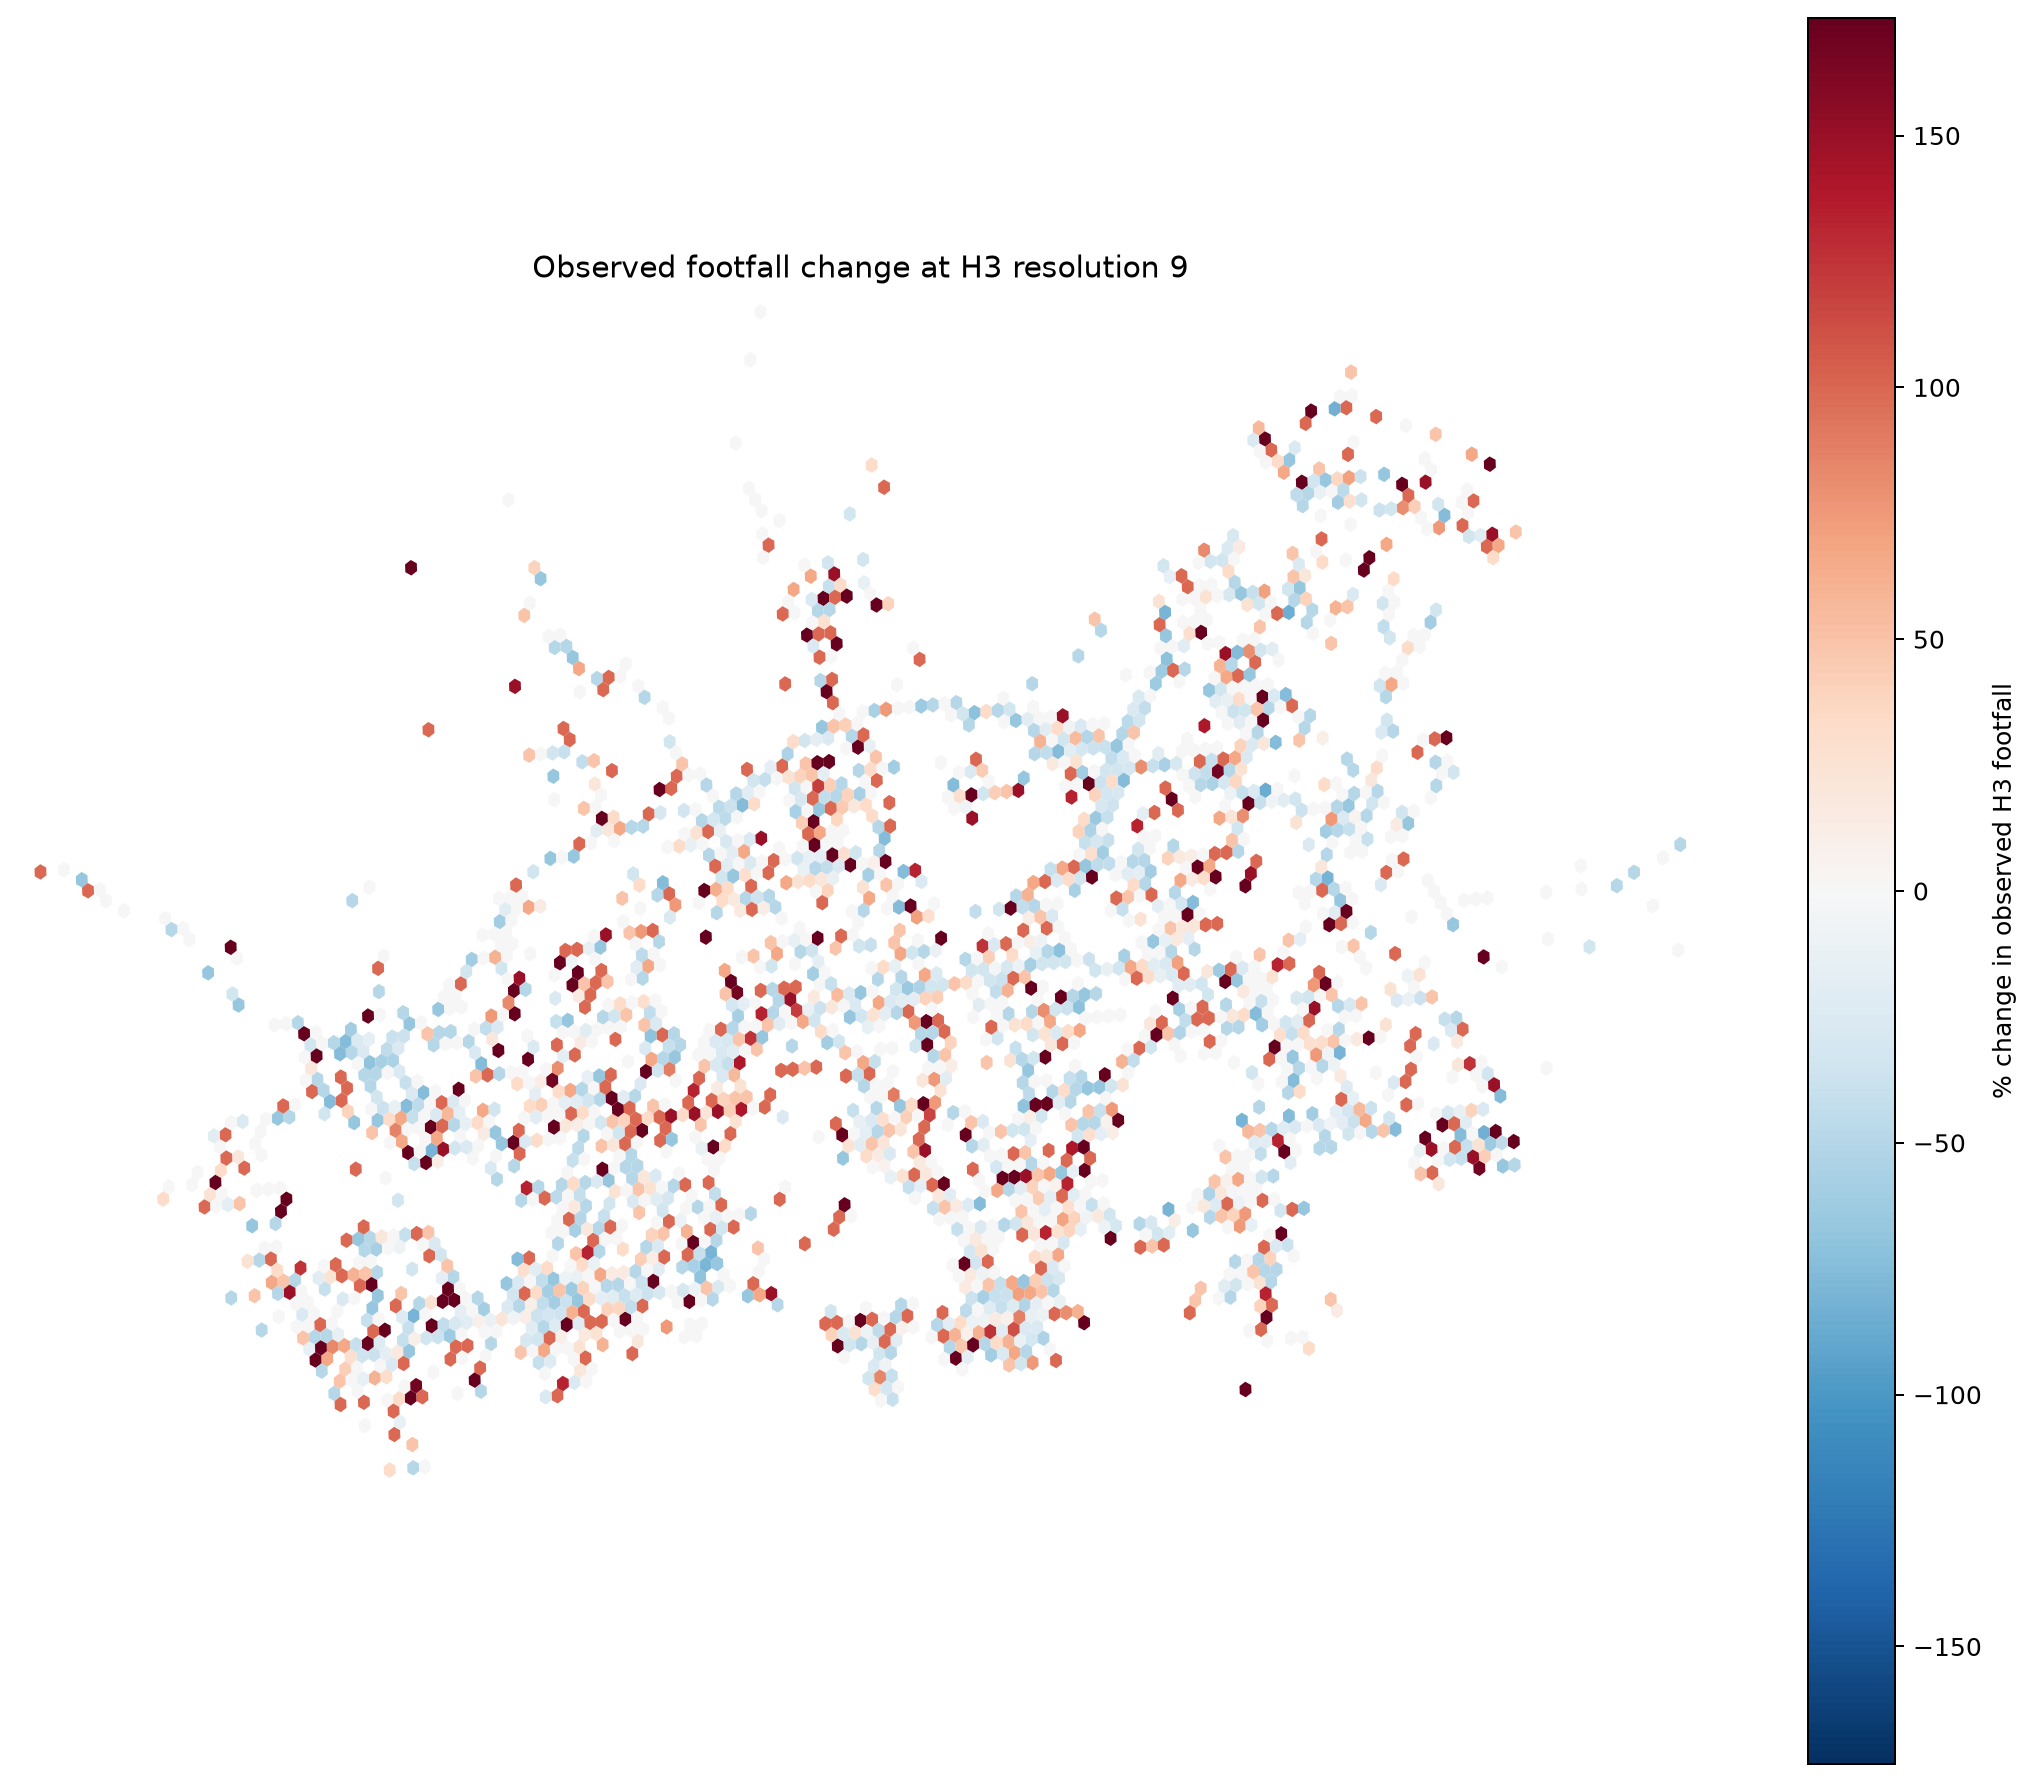

In [10]:
plot_data = h3_display.dropna(
    subset=["pct_change_footfall"]
).copy()

limit = np.nanpercentile(
    np.abs(plot_data["pct_change_footfall"]),
    95,
)

if not np.isfinite(limit) or limit == 0:
    limit = 1

plot_h3_surface(
    plot_data,
    column="pct_change_footfall",
    title=f"Observed footfall change at H3 resolution {MAP_H3_RESOLUTION}",
    legend_label="% change in observed H3 footfall",
    cmap="RdBu_r",
    vmin=-limit,
    vmax=limit,
)


## 7. Map H3 persistence ratio

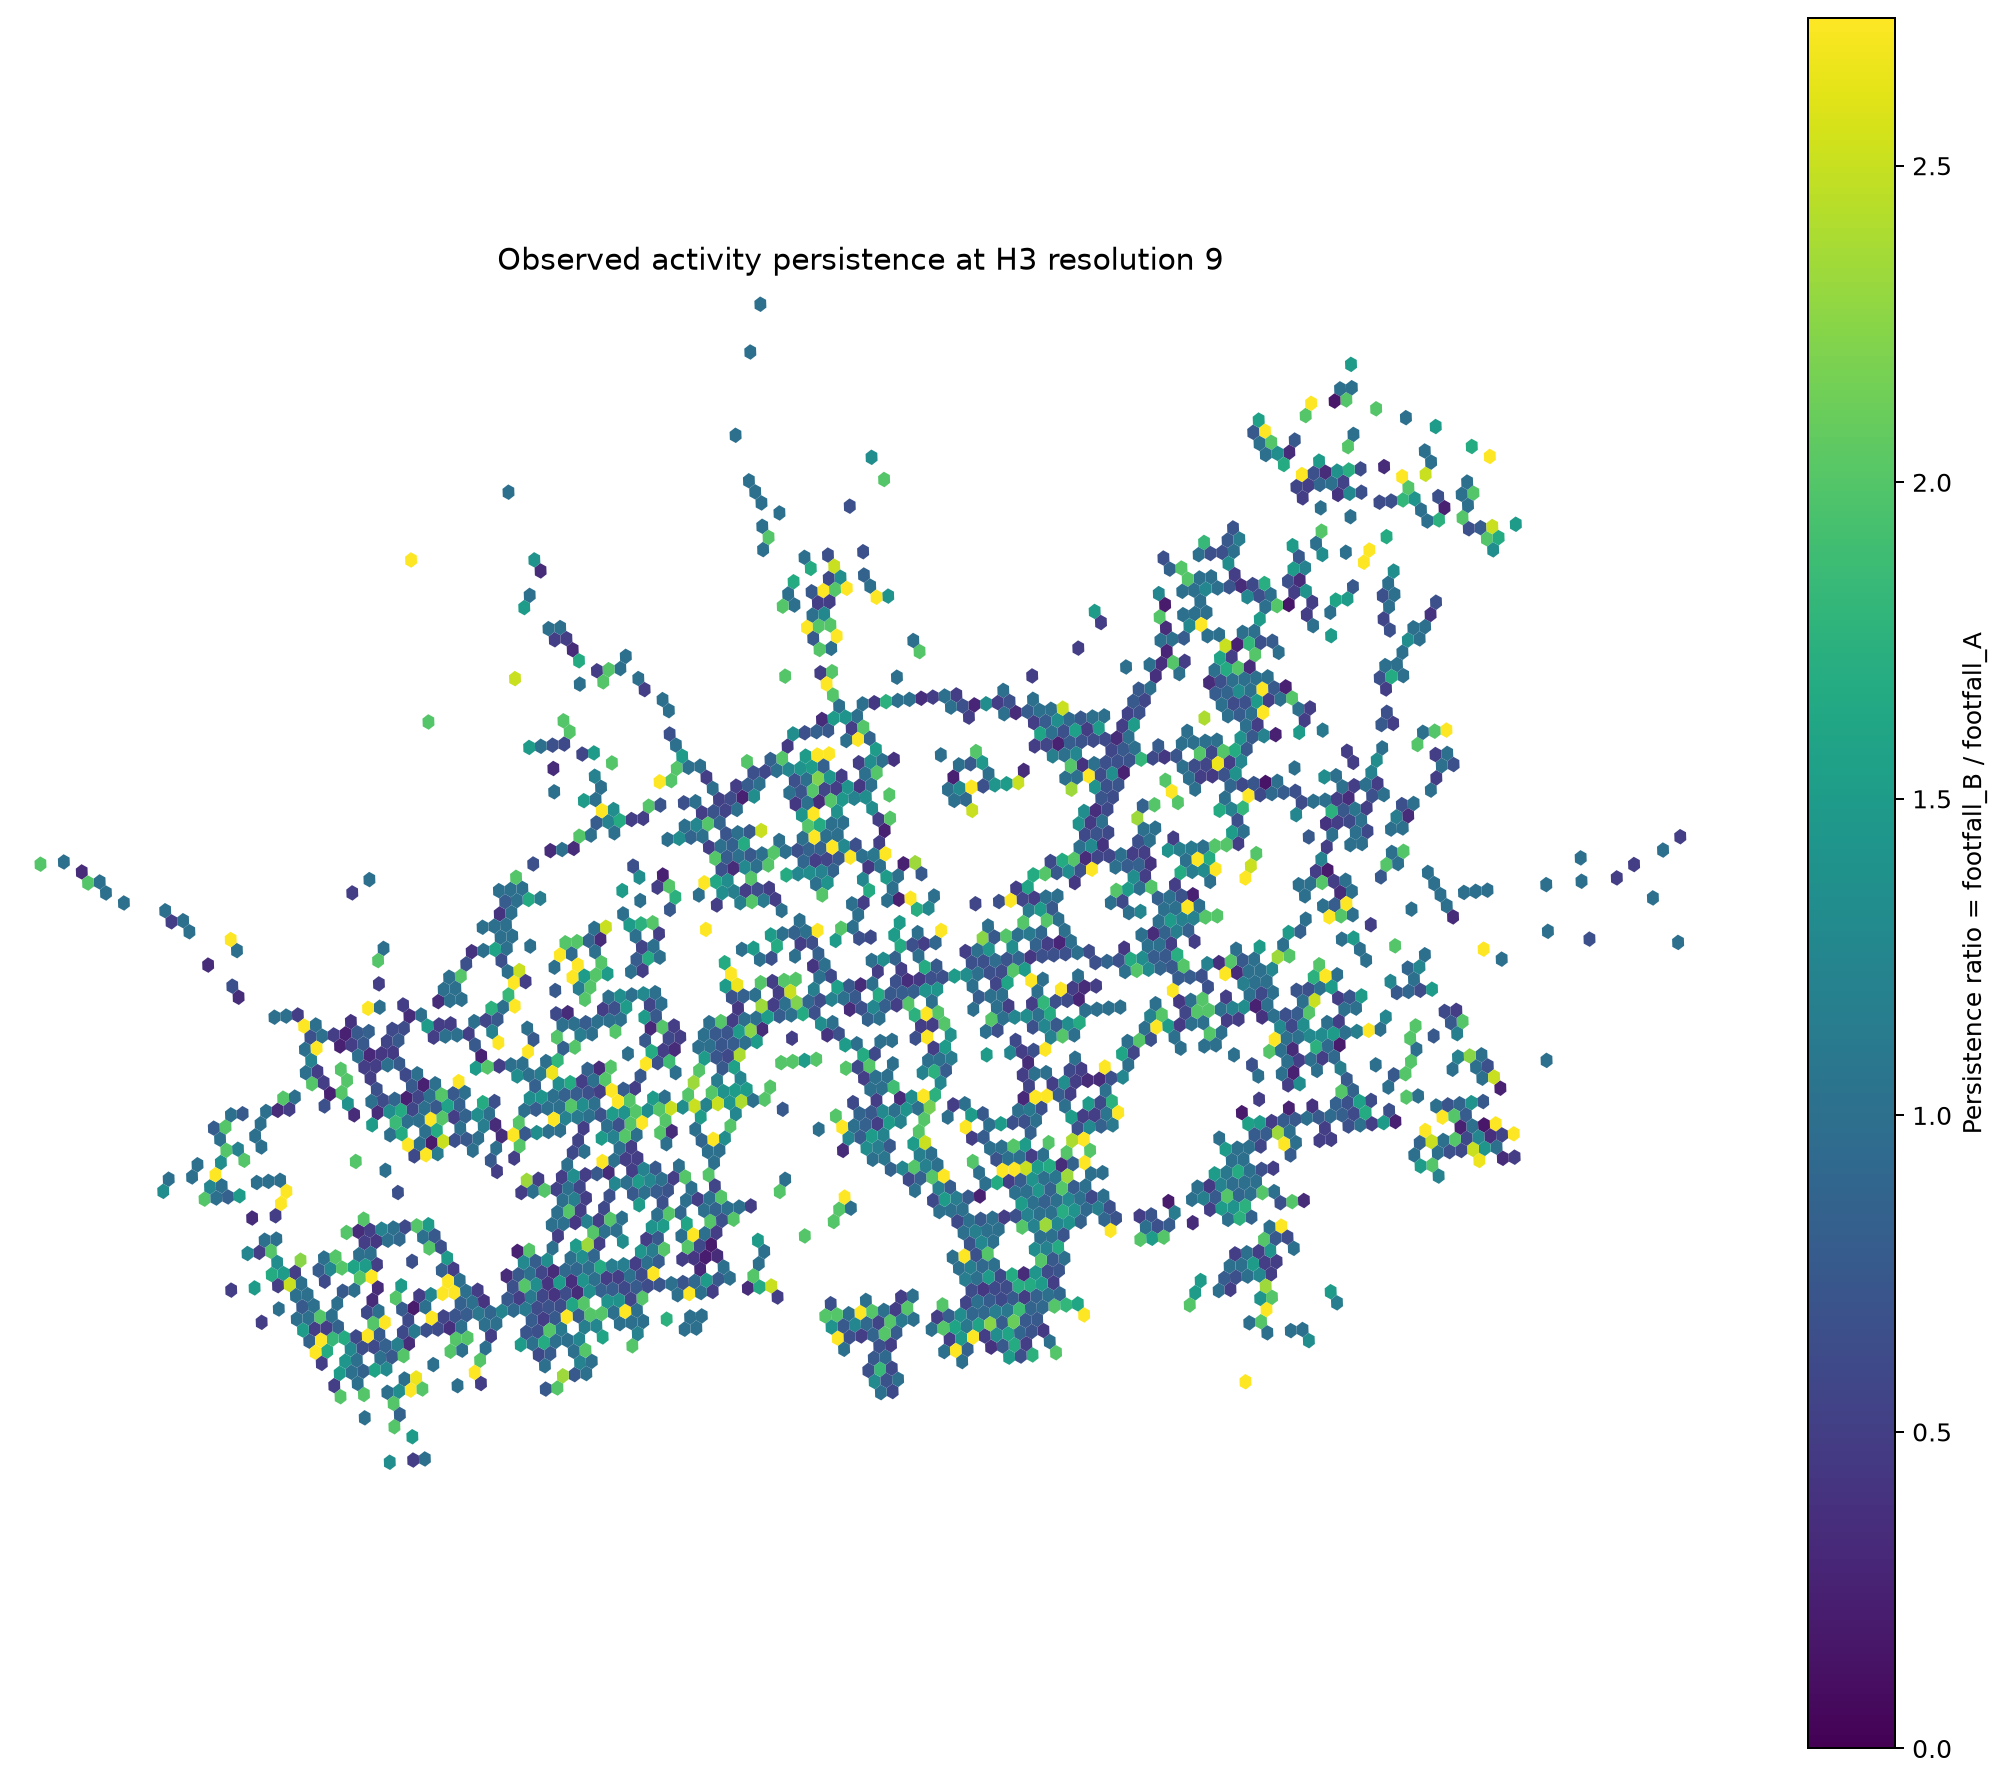

In [11]:
persistence_map = h3_display.dropna(
    subset=["persistence_ratio"]
).copy()

upper = np.nanpercentile(
    persistence_map["persistence_ratio"],
    95,
)

if not np.isfinite(upper):
    upper = 1.5

plot_h3_surface(
    persistence_map,
    column="persistence_ratio",
    title=f"Observed activity persistence at H3 resolution {MAP_H3_RESOLUTION}",
    legend_label="Persistence ratio = footfall_B / footfall_A",
    cmap="viridis",
    vmin=0,
    vmax=max(1.5, upper),
)


## 8. Map simple behavioural classes

Three classes only:
- decreased
- broadly stable
- increased


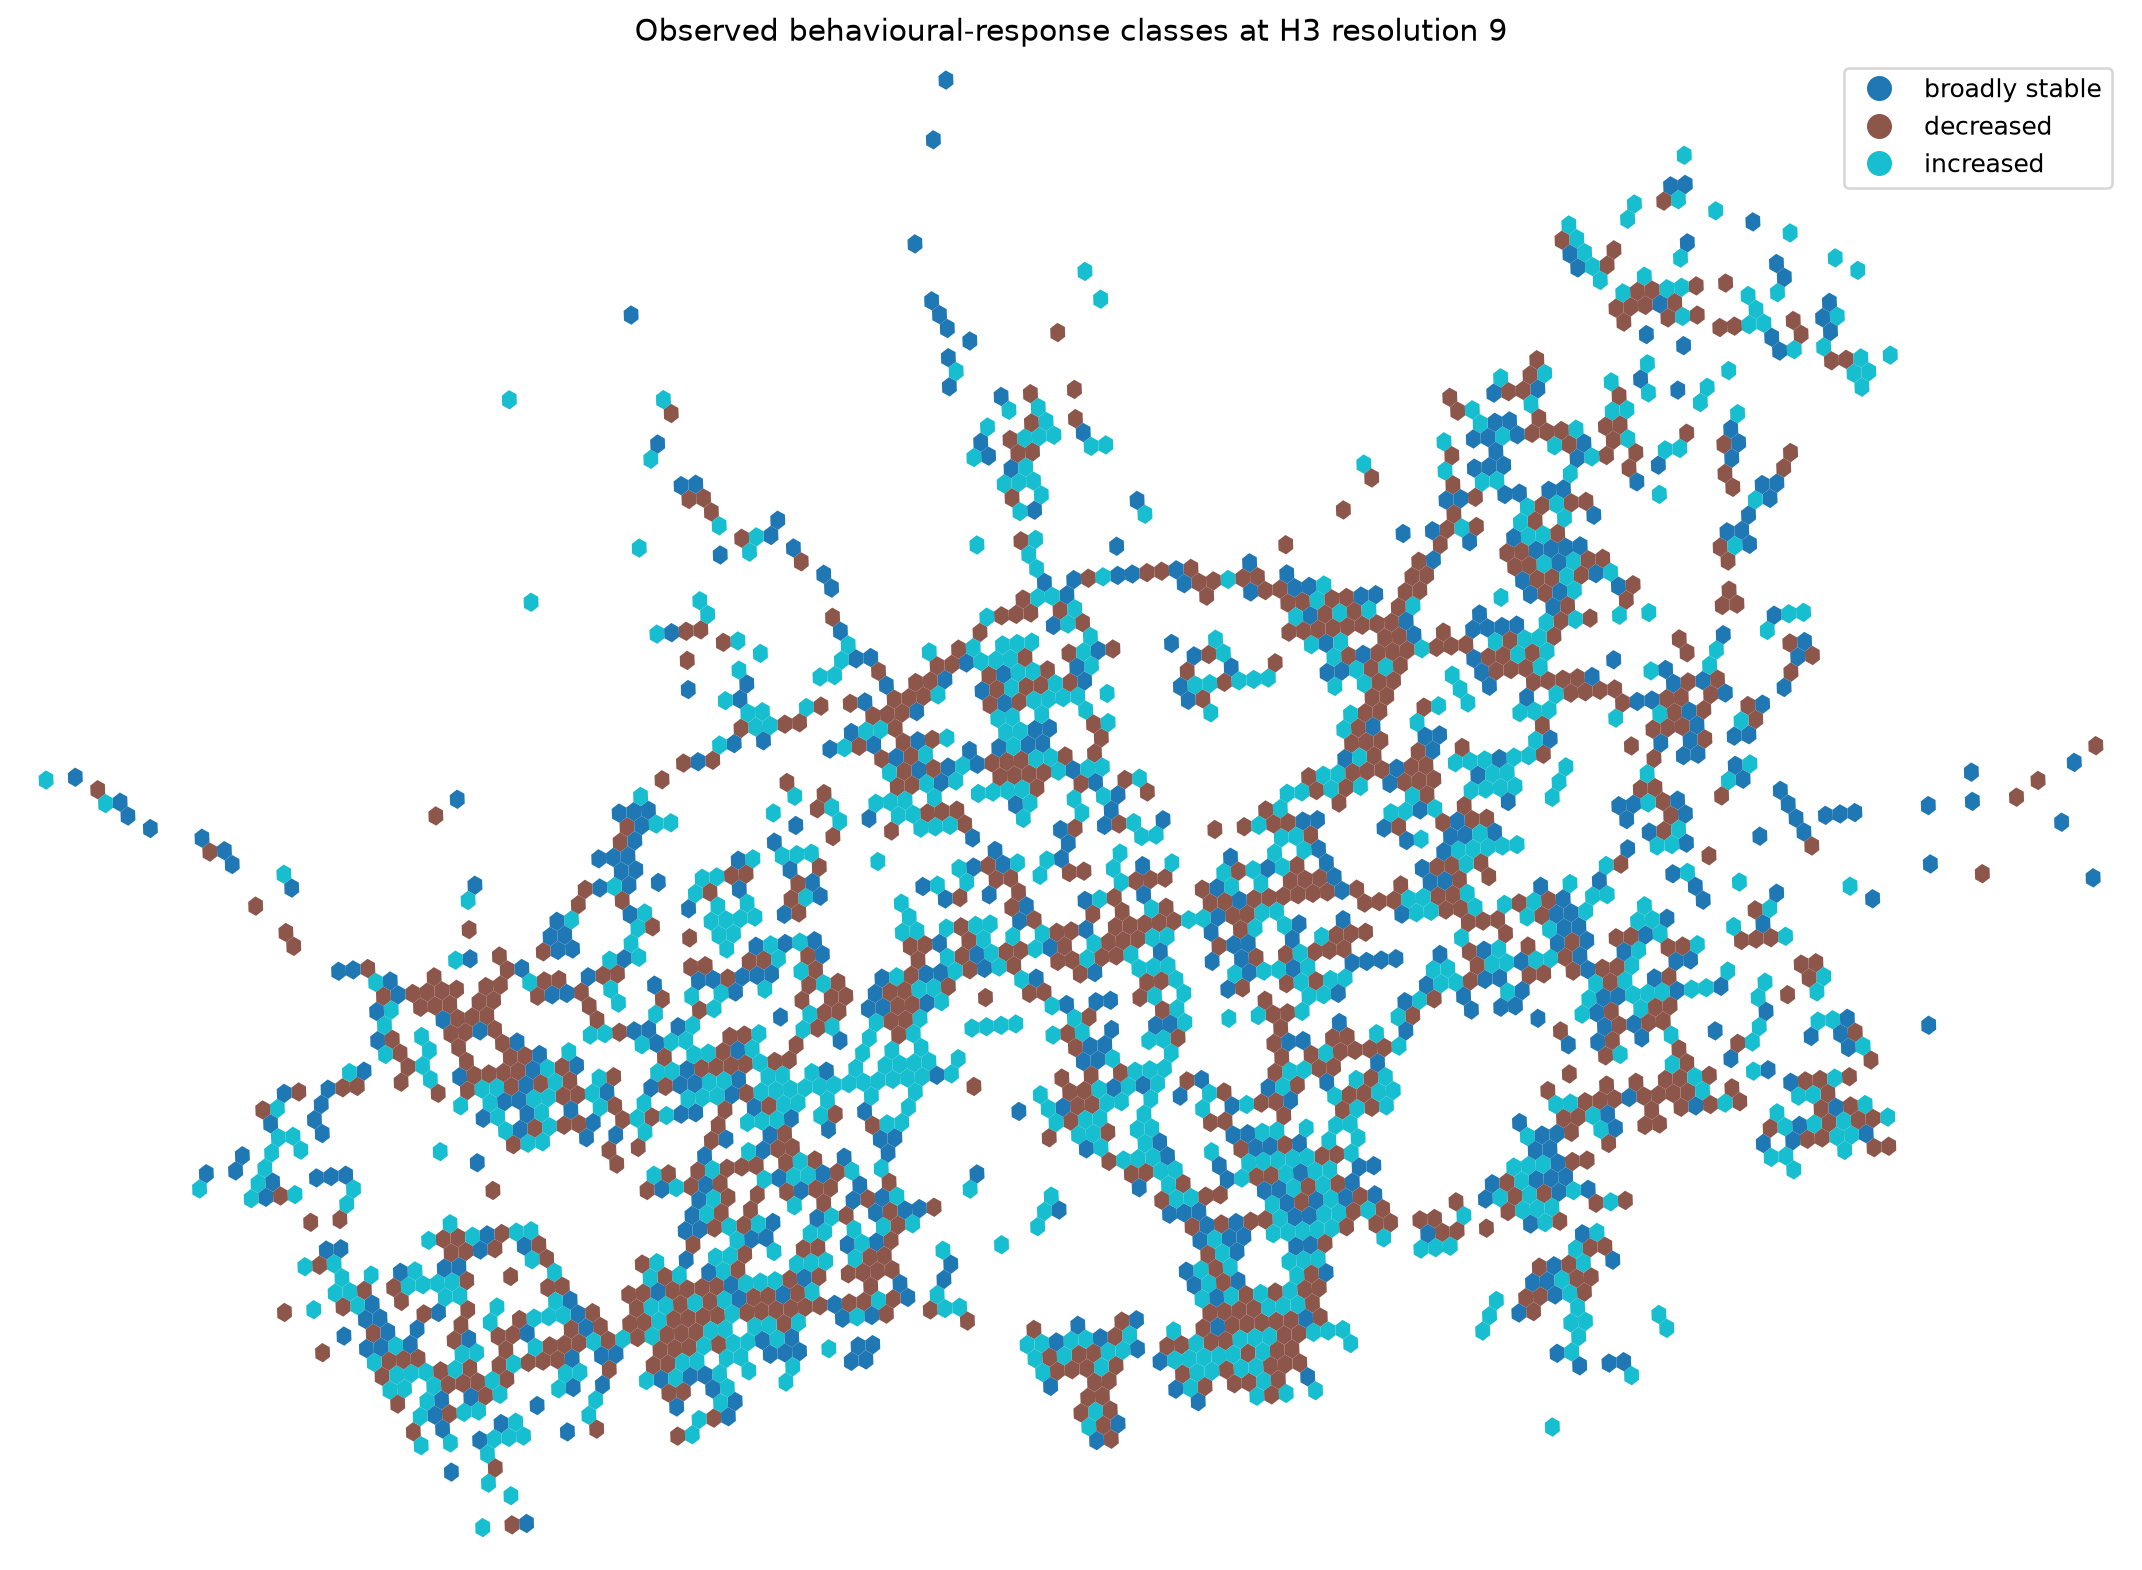

In [12]:
plot_h3_surface(
    h3_display,
    column="behavior_class",
    title=f"Observed behavioural-response classes at H3 resolution {MAP_H3_RESOLUTION}",
    legend_label="Behaviour class",
    categorical=True,
)


## 9. Map absolute activity loss

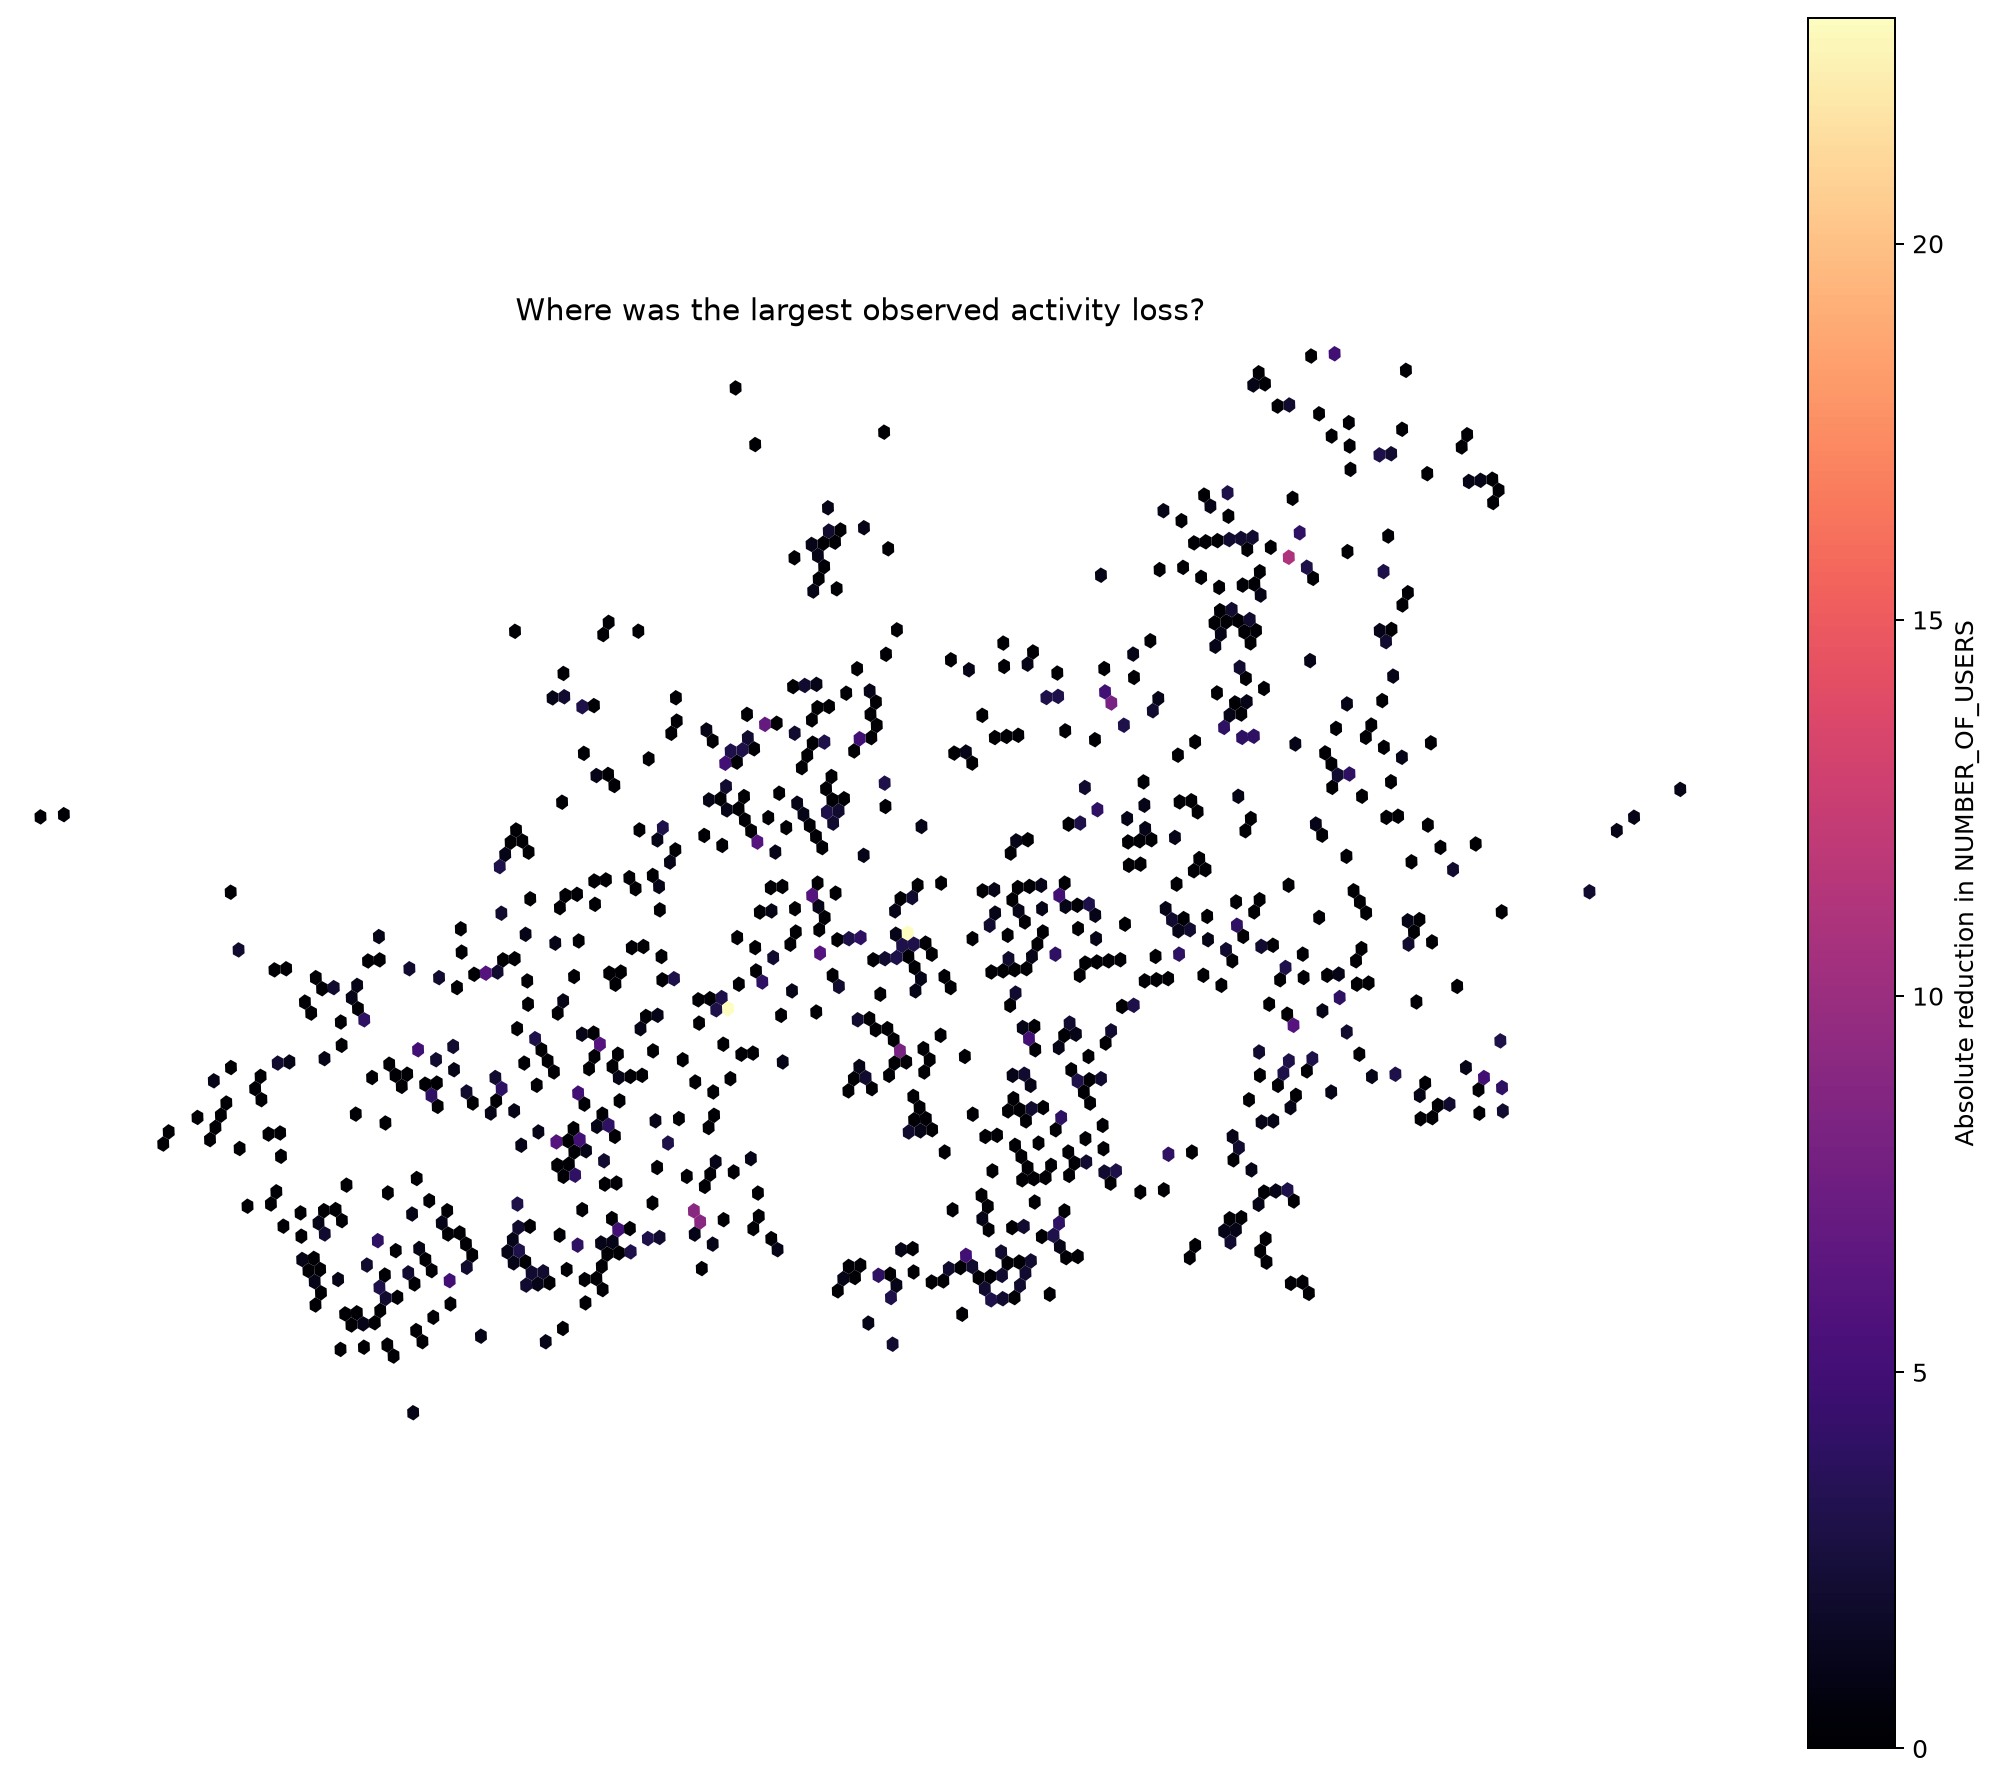

In [13]:
loss_map = h3_display.loc[
    h3["absolute_activity_loss"] > 0
].copy()

if not loss_map.empty:
    plot_h3_surface(
        loss_map,
        column="absolute_activity_loss",
        title="Where was the largest observed activity loss?",
        legend_label="Absolute reduction in NUMBER_OF_USERS",
        cmap="magma",
    )


## 10. Map absolute activity gain

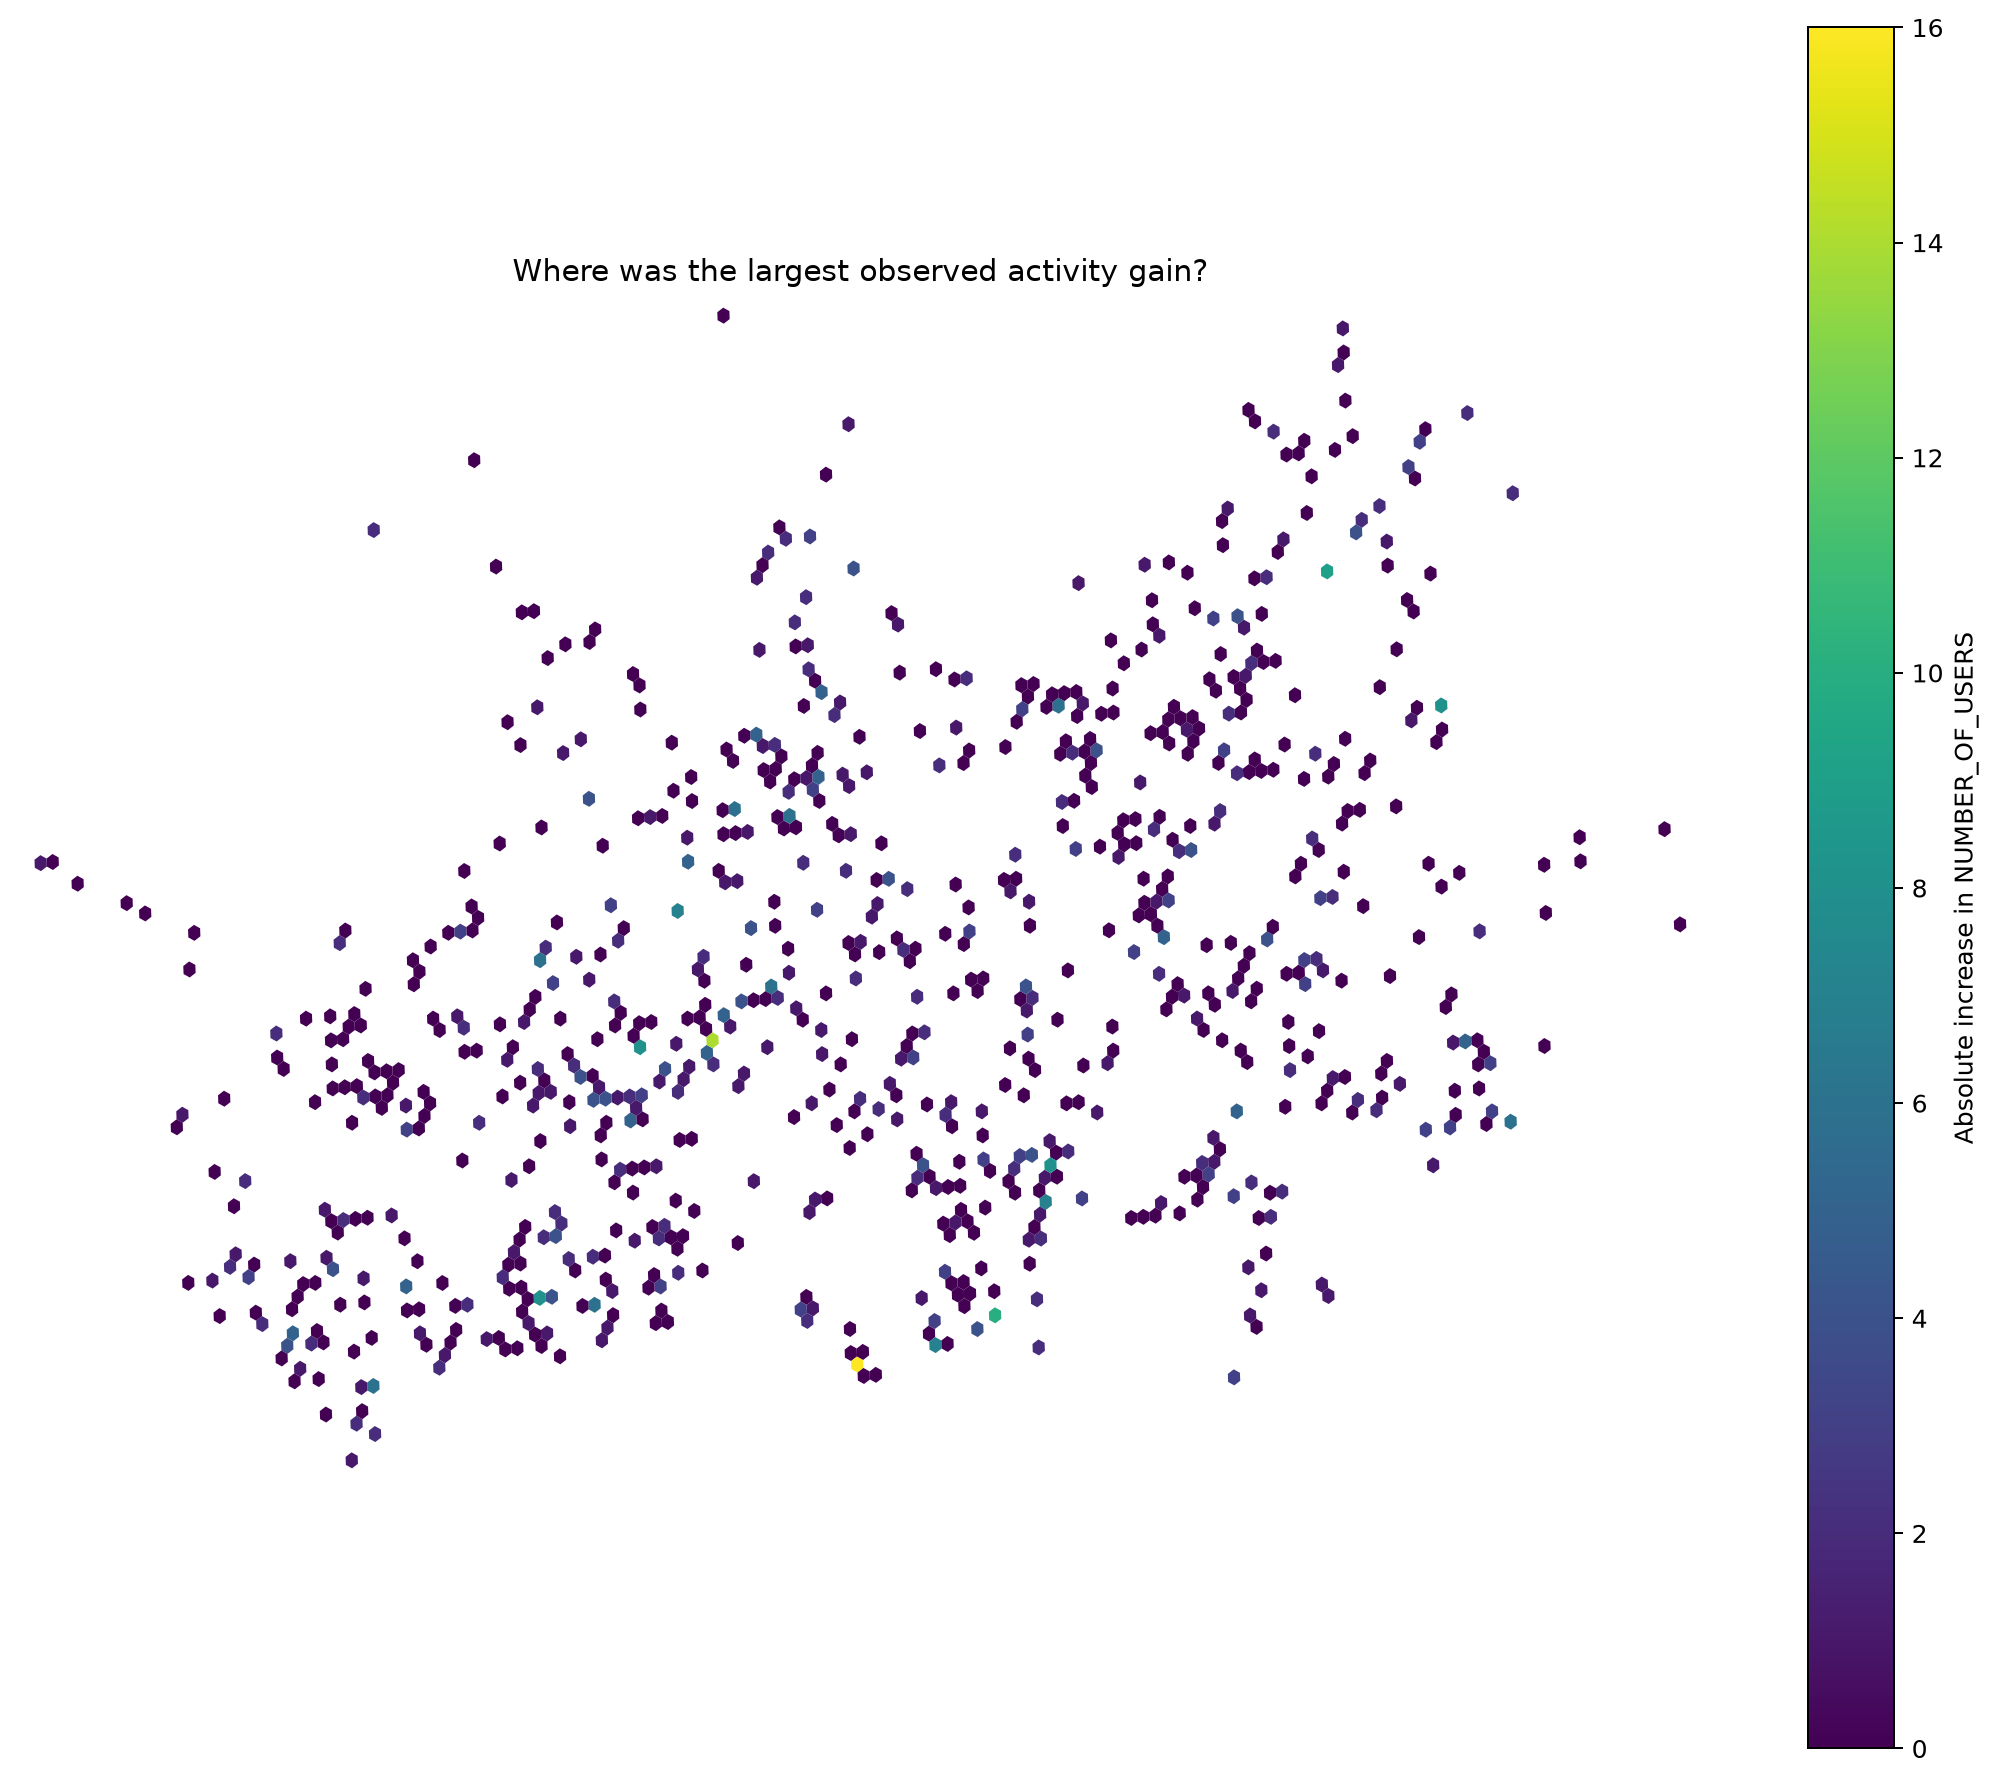

In [14]:
gain_map = h3_display.loc[
    h3["absolute_activity_gain"] > 0
].copy()

if not gain_map.empty:
    plot_h3_surface(
        gain_map,
        column="absolute_activity_gain",
        title="Where was the largest observed activity gain?",
        legend_label="Absolute increase in NUMBER_OF_USERS",
        cmap="viridis",
    )


## 11. Rank strongest H3 declines and persistence

In [15]:
top_declines = (
    h3.dropna(subset=["pct_change_footfall"])
    .sort_values("pct_change_footfall")
    [
        [
            "CODE",
            "footfall_A",
            "footfall_B",
            "absolute_activity_change",
            "pct_change_footfall",
            "persistence_ratio",
        ]
    ]
    .head(20)
)

top_persistent = (
    h3.dropna(subset=["persistence_ratio"])
    .sort_values("persistence_ratio", ascending=False)
    [
        [
            "CODE",
            "footfall_A",
            "footfall_B",
            "absolute_activity_change",
            "pct_change_footfall",
            "persistence_ratio",
        ]
    ]
    .head(20)
)

print("Strongest declines")
display(top_declines)

print("Strongest persistence / increase")
display(top_persistent)


Strongest declines


,CODE,footfall_A,footfall_B,absolute_activity_change,pct_change_footfall,persistence_ratio
4795,8a0899698d6ffff,18,2,-16,-88.888889,0.111111
4520,8a1126d46937fff,8,1,-7,-87.500000,0.125000
1120,8a1126d338cffff,8,1,-7,-87.500000,0.125000
4410,8a08996988b7fff,8,1,-7,-87.500000,0.125000
4212,8a1126d2188ffff,8,1,-7,-87.500000,0.125000
2168,8a0899688d0ffff,8,1,-7,-87.500000,0.125000
1942,8a1126c35367fff,8,1,-7,-87.500000,0.125000
4727,8a08996a1457fff,8,1,-7,-87.500000,0.125000
1821,8a08996d5d0ffff,7,1,-6,-85.714286,0.142857
4104,8a1126d720f7fff,7,1,-6,-85.714286,0.142857


Strongest persistence / increase


,CODE,footfall_A,footfall_B,absolute_activity_change,pct_change_footfall,persistence_ratio
641,8a1126d33ce7fff,1,9,8,800.0,9.0
2970,8a0899689c4ffff,1,8,7,700.0,8.0
3095,8a1126d26b9ffff,1,7,6,600.0,7.0
765,8a1126d20547fff,1,7,6,600.0,7.0
2983,8a08996d0d6ffff,1,7,6,600.0,7.0
1068,8a089968598ffff,1,6,5,500.0,6.0
516,8a089968b837fff,1,6,5,500.0,6.0
3368,8a08996d260ffff,1,6,5,500.0,6.0
4121,8a0899685877fff,1,6,5,500.0,6.0
4197,8a1126d0600ffff,1,6,5,500.0,6.0


## 12. Baseline activity vs behavioural change

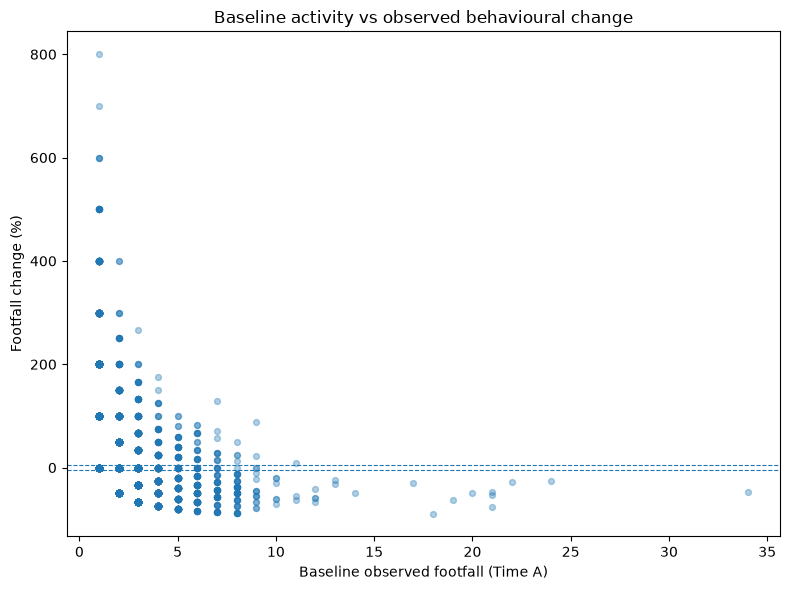

In [16]:
scatter = h3.dropna(
    subset=["footfall_A", "pct_change_footfall"]
).copy()

fig, ax = plt.subplots(figsize=(8, 6))

ax.scatter(
    scatter["footfall_A"],
    scatter["pct_change_footfall"],
    alpha=0.35,
    s=18,
)

ax.axhline(
    -STABLE_THRESHOLD_PCT,
    linestyle="--",
    linewidth=0.8,
)

ax.axhline(
    STABLE_THRESHOLD_PCT,
    linestyle="--",
    linewidth=0.8,
)

ax.set_xlabel("Baseline observed footfall (Time A)")
ax.set_ylabel("Footfall change (%)")
ax.set_title("Baseline activity vs observed behavioural change")

plt.tight_layout()
plt.show()


## 13. Higher-baseline-activity H3 cells only

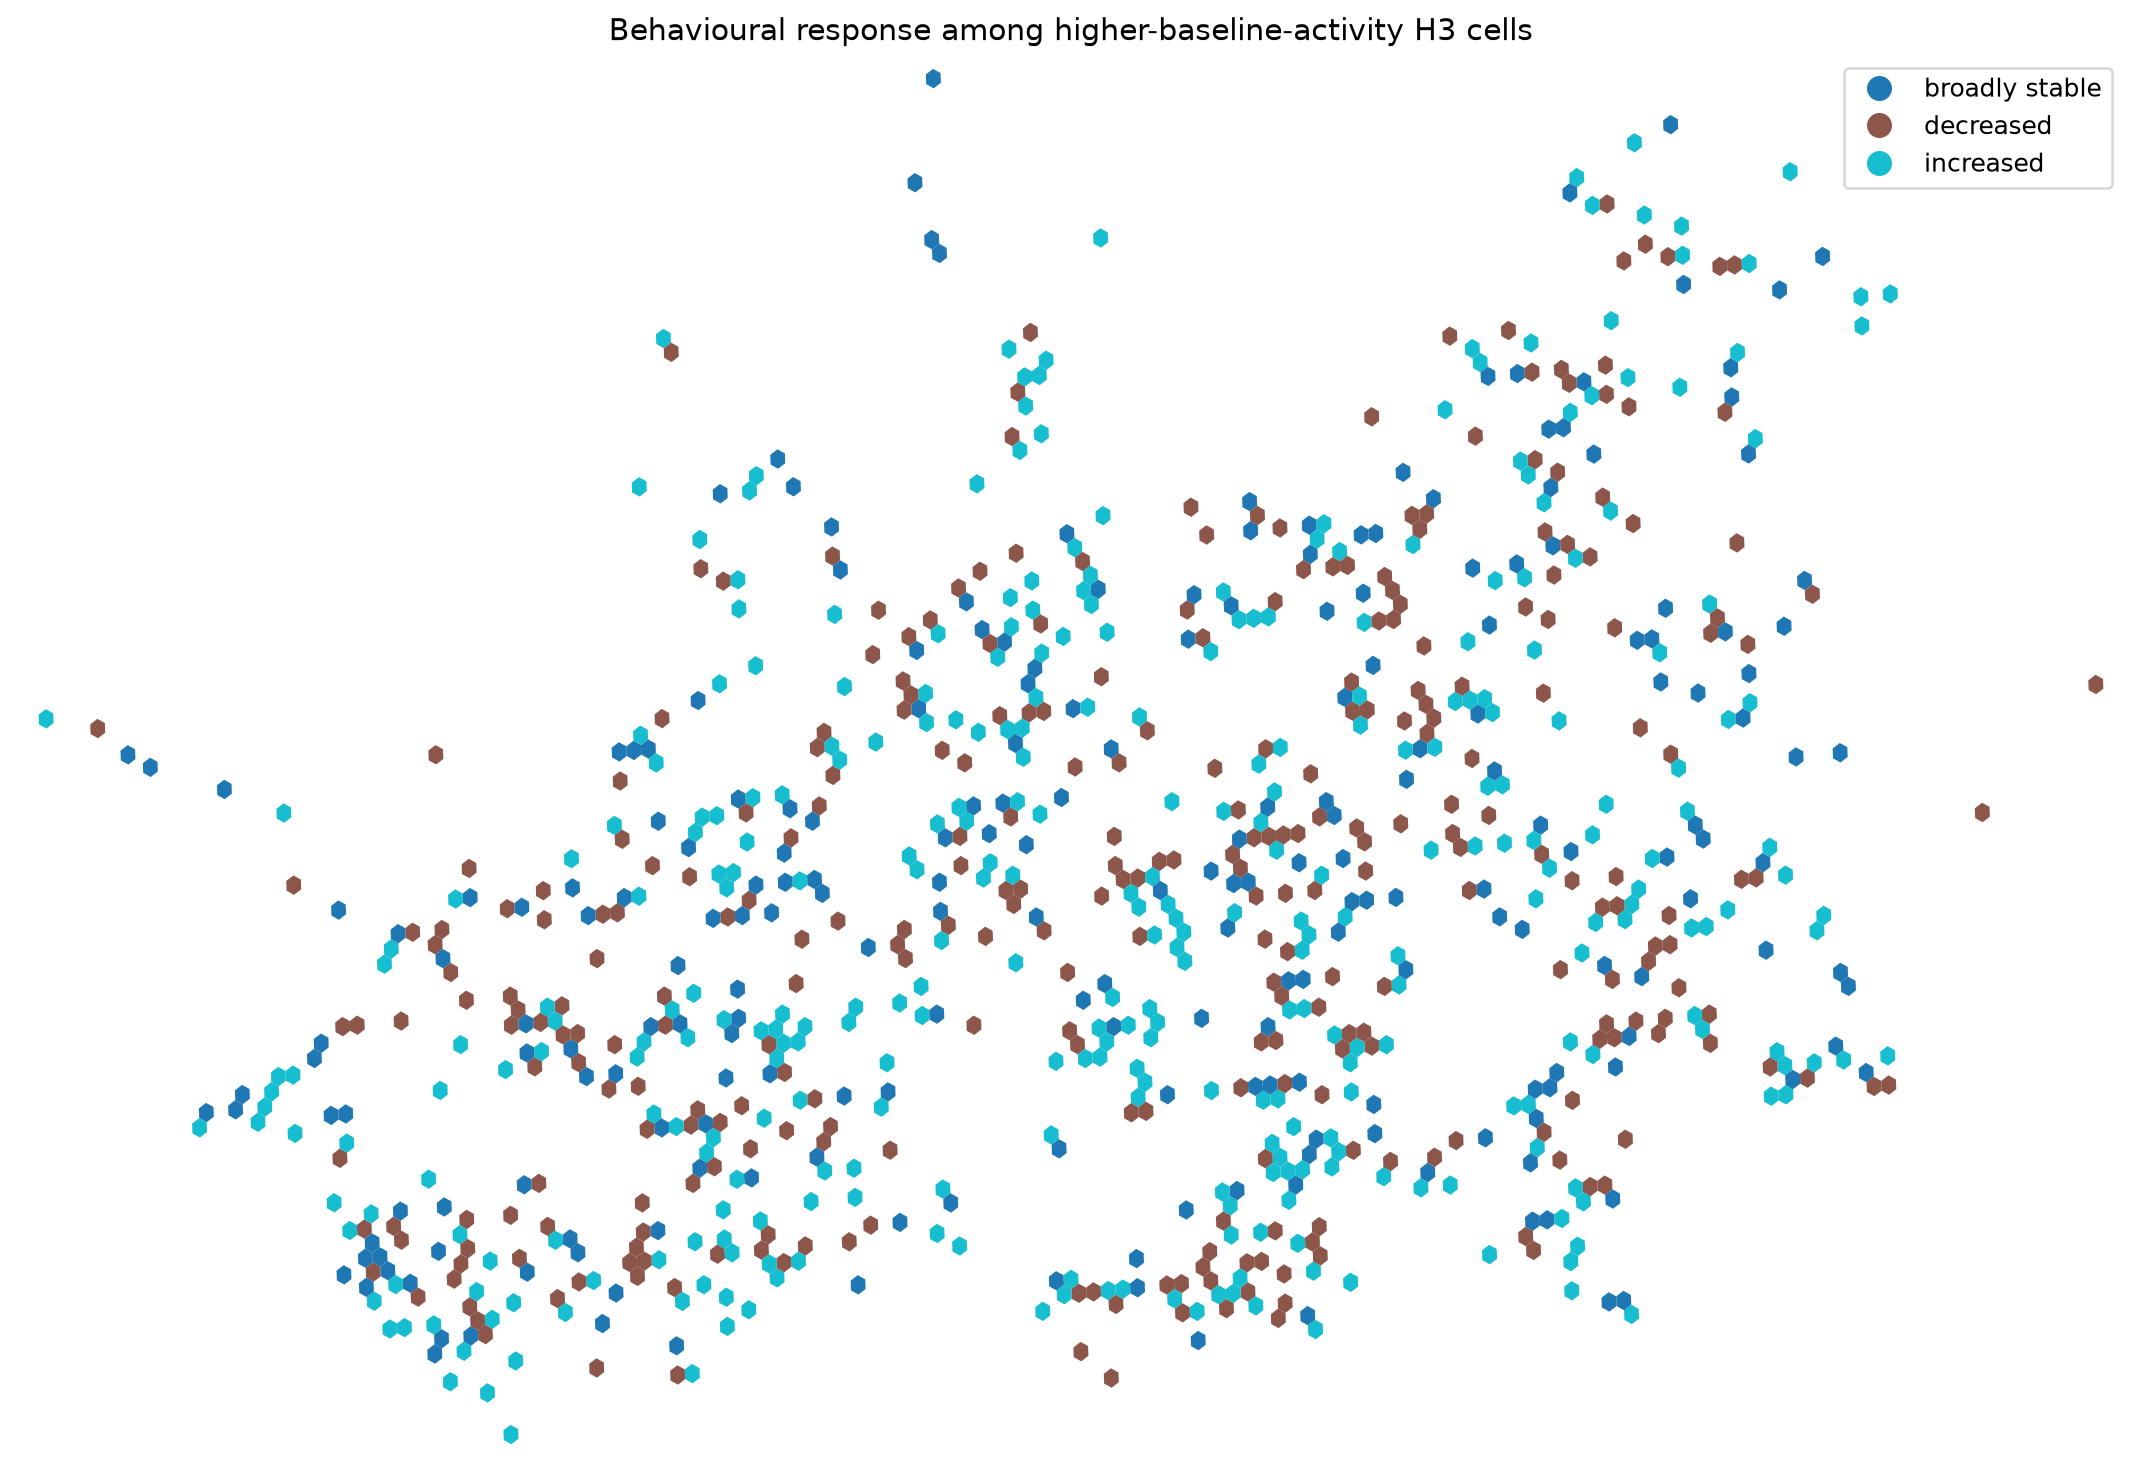

Baseline median NUMBER_OF_USERS: 3.0


In [17]:
baseline_median = h3_display["footfall_A"].median()

high_activity = h3_display.loc[
    h3["footfall_A"] >= baseline_median
].copy()

plot_h3_surface(
    high_activity,
    column="behavior_class",
    title="Behavioural response among higher-baseline-activity H3 cells",
    legend_label="Behaviour class",
    categorical=True,
)

print("Baseline median NUMBER_OF_USERS:", baseline_median)


## 14. Secondary neighbourhood summary

Neighbourhoods are retained only as a **summary geography**.  
The H3 response remains the primary analysis.


In [18]:
units = gpd.read_file(
    helsinki.mobility.neighbourhoods
)

units["unit_id"] = (
    units["Neighbourhood_unit_ID"].astype("Int64")
)

neighbourhoods = units[
    [
        "unit_id",
        "Neighbourhood_name",
        "Municipality_name",
        "geometry",
    ]
].copy()

h3_proj = h3.to_crs(neighbourhoods.crs).copy()

h3_points = h3_proj.copy()
h3_points["geometry"] = h3_points.geometry.representative_point()

joined = gpd.sjoin(
    h3_points,
    neighbourhoods,
    predicate="within",
    how="left",
)

matched = joined.loc[
    joined["unit_id"].notna()
].copy()

print("Matched H3 cells:", len(matched), "/", len(joined))


Matched H3 cells: 4873 / 4873


## 15. Aggregate behavioural response by neighbourhood

In [19]:
neighbourhood_summary = (
    matched
    .groupby(
        [
            "unit_id",
            "Neighbourhood_name",
            "Municipality_name",
        ],
        as_index=False,
    )
    .agg(
        n_h3_cells=("CODE", "nunique"),
        footfall_A_sum=("footfall_A", "sum"),
        footfall_B_sum=("footfall_B", "sum"),
        median_h3_pct_change=("pct_change_footfall", "median"),
        mean_h3_pct_change=("pct_change_footfall", "mean"),
        median_persistence_ratio=("persistence_ratio", "median"),
    )
)

neighbourhood_summary["footfall_sum_pct_change"] = np.where(
    neighbourhood_summary["footfall_A_sum"] > 0,
    100
    * (
        neighbourhood_summary["footfall_B_sum"]
        - neighbourhood_summary["footfall_A_sum"]
    )
    / neighbourhood_summary["footfall_A_sum"],
    np.nan,
)

display(
    neighbourhood_summary.sort_values(
        "footfall_sum_pct_change"
    ).head(20)
)


,unit_id,Neighbourhood_name,Municipality_name,n_h3_cells,footfall_A_sum,footfall_B_sum,median_h3_pct_change,mean_h3_pct_change,median_persistence_ratio,footfall_sum_pct_change
17,492021211,Tapiolan Keskus,Espoo,23,91,44,-33.333333,-19.516908,0.666667,-51.648352
66,496063631,Karvasmäki,Espoo,19,59,29,-50.000000,-41.478697,0.500000,-50.847458
216,918801592,Puroniitty,Helsinki,1,2,1,-50.000000,-50.000000,0.500000,-50.000000
198,917701455,Marjaniemi,Helsinki,1,2,1,-50.000000,-50.000000,0.500000,-50.000000
136,913303213,Kyläsaari,Helsinki,1,2,1,-50.000000,-50.000000,0.500000,-50.000000
94,911103202,Lapinlahti,Helsinki,4,13,7,-50.000000,-32.500000,0.500000,-46.153846
251,924069000,Helsingin pitäjän kirkonkylä,Vantaa,5,13,7,-50.000000,-45.000000,0.500000,-46.153846
199,917701456,Roihupelto,Helsinki,10,29,16,-50.000000,-35.833333,0.500000,-44.827586
19,492021213,Otsolahti,Espoo,2,7,4,-25.000000,-25.000000,0.750000,-42.857143
58,496061611,Kirkkojärvi,Espoo,20,41,25,-33.333333,-28.750000,0.666667,-39.024390


## 16. Aggregated H3 behavioural-response surface

This map uses the same Locomizer observations but aggregates the native H3-10 cells into **larger H3-9 parent cells** for easier visual interpretation at metropolitan scale.

The original H3-10 data remain unchanged and are still saved separately.


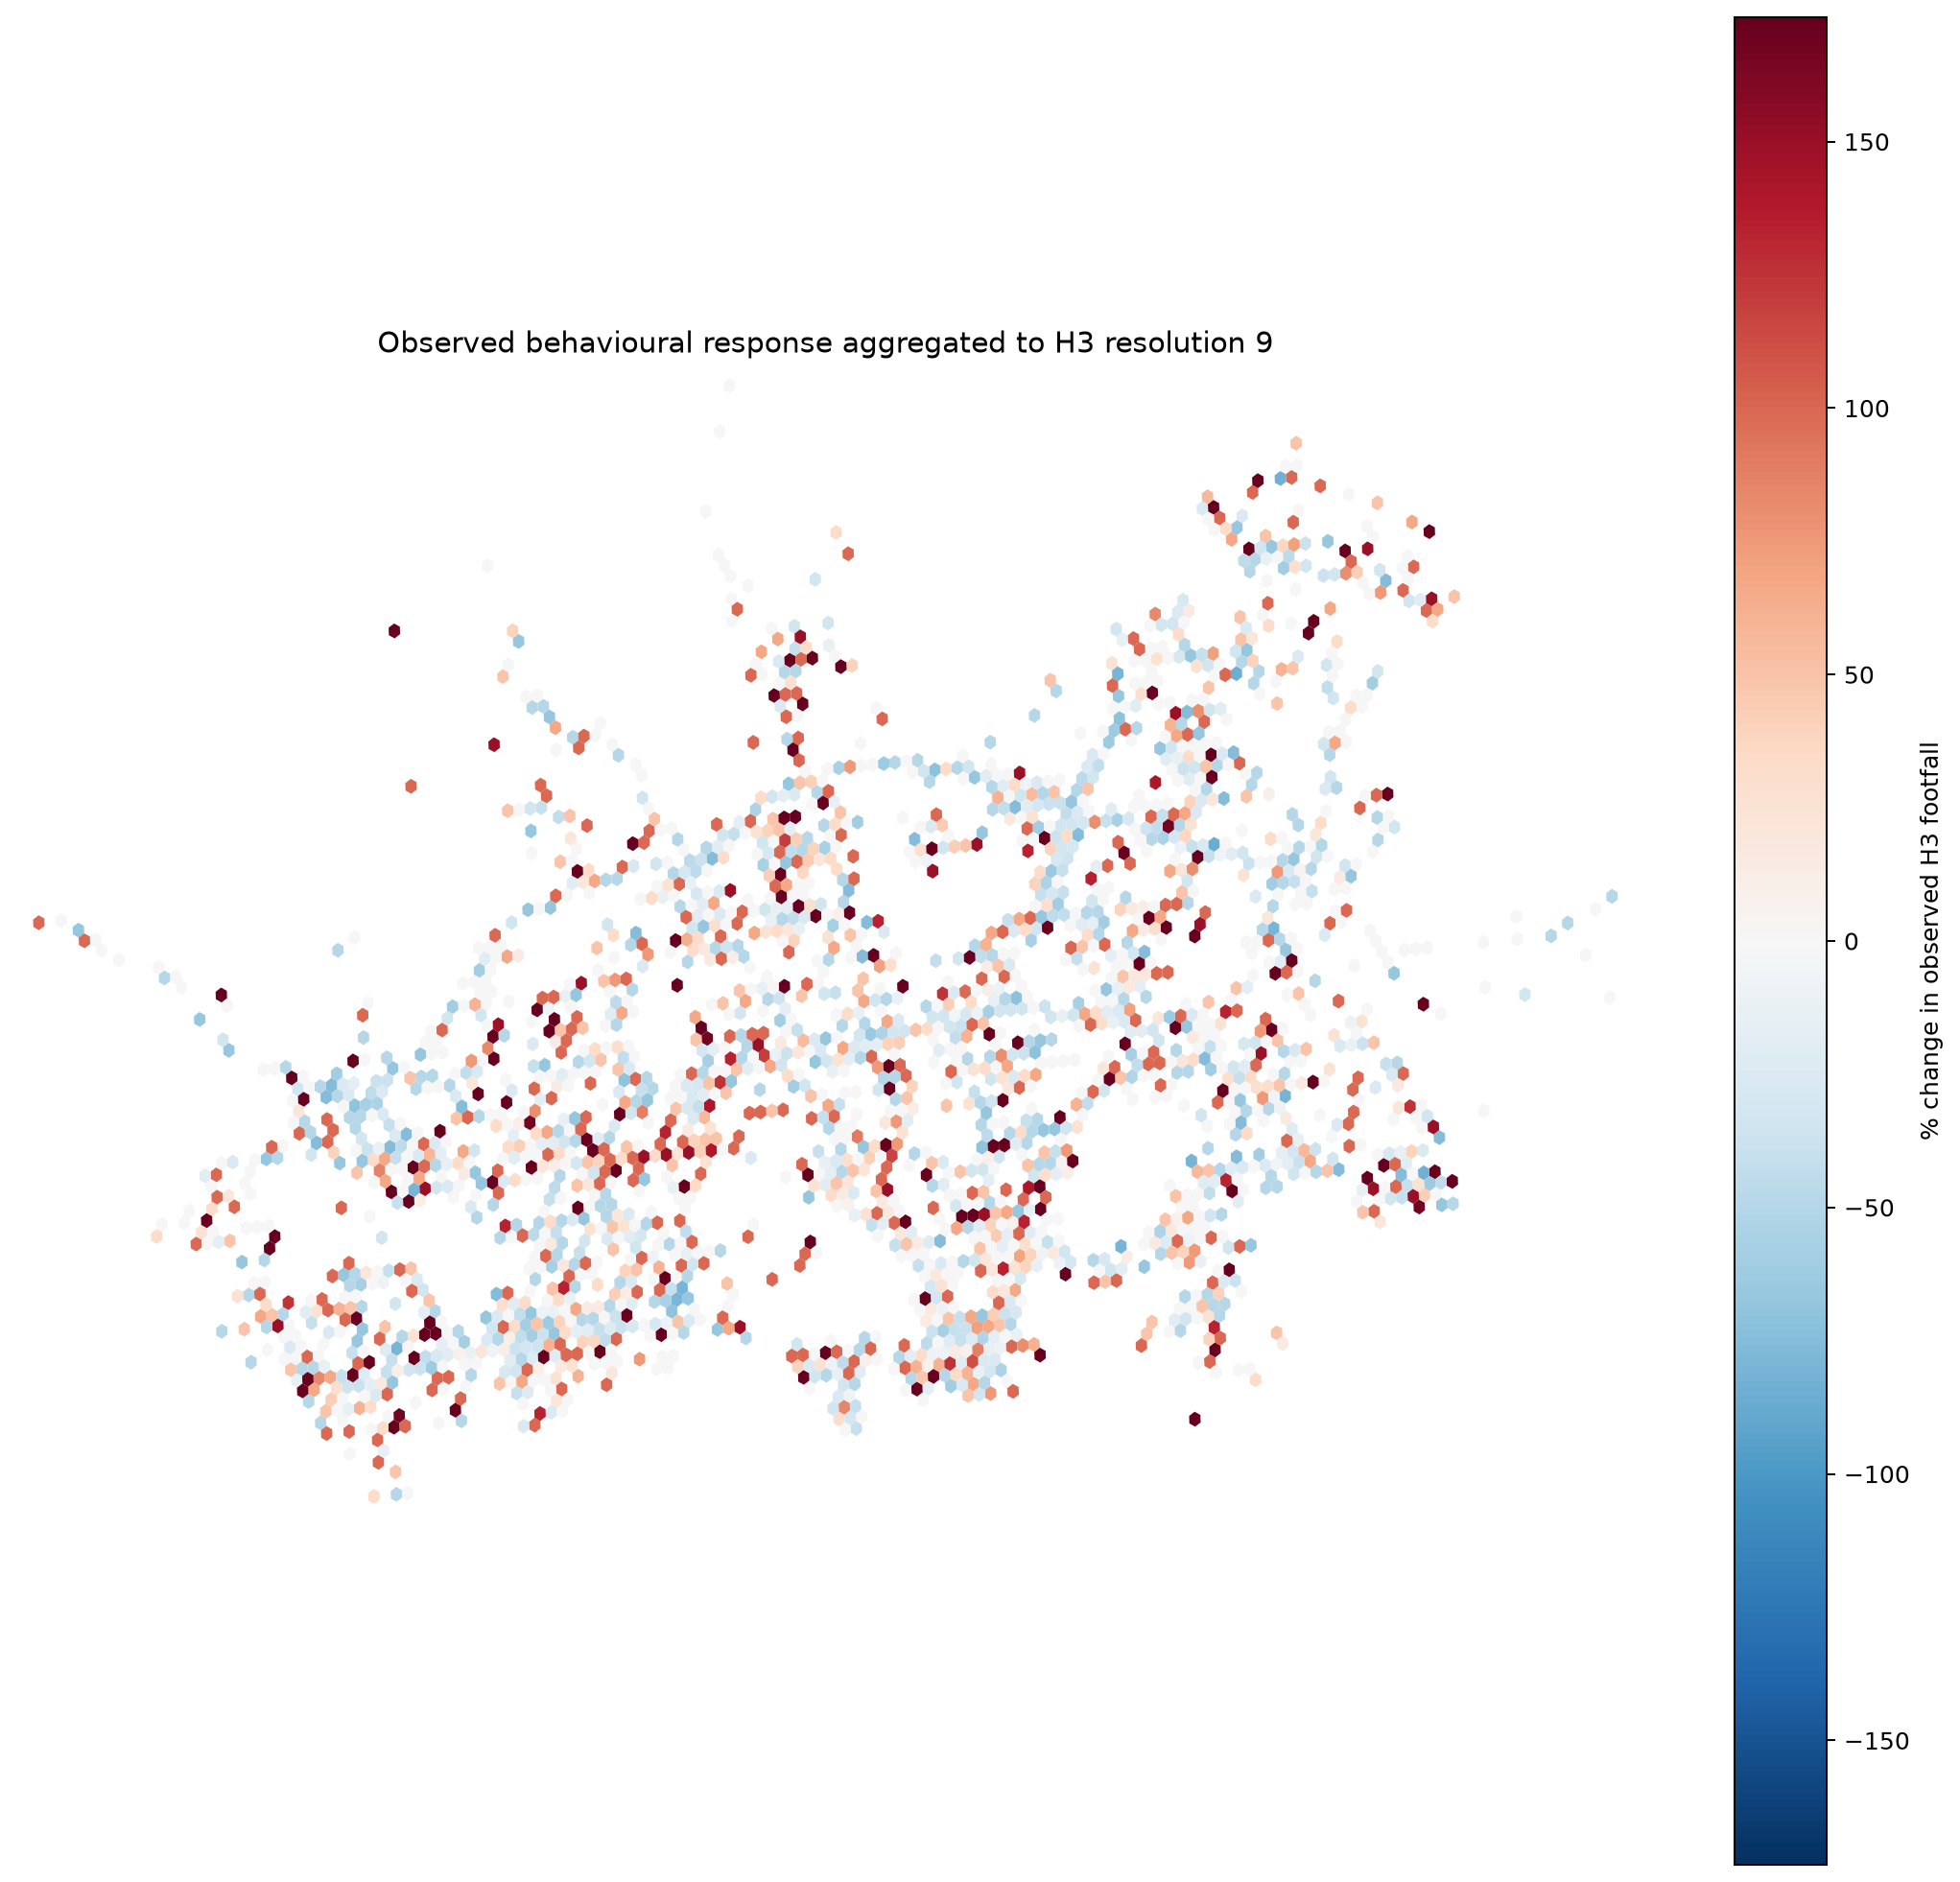

In [20]:
h3_map = h3_display.dropna(
    subset=["pct_change_footfall"]
).copy()

limit = np.nanpercentile(
    np.abs(h3_map["pct_change_footfall"]),
    95,
)

if not np.isfinite(limit) or limit == 0:
    limit = 1

plot_h3_surface(
    h3_map,
    column="pct_change_footfall",
    title=f"Observed behavioural response aggregated to H3 resolution {MAP_H3_RESOLUTION}",
    legend_label="% change in observed H3 footfall",
    cmap="RdBu_r",
    vmin=-limit,
    vmax=limit,
    figsize=(12, 11),
)


## 17. Does the selected PM₂.₅ event pair represent worsening air?

In [21]:
current_delta_pm25 = (
    h3["regional_delta_pm25_median"]
    .dropna()
    .iloc[0]
)

print(
    "Regional median ΔPM2.5:",
    current_delta_pm25,
    "µg/m³",
)

if current_delta_pm25 > 0:
    print("The selected pair represents worsening regional PM2.5.")
elif current_delta_pm25 < 0:
    print("The selected pair represents improving regional PM2.5.")
else:
    print("Regional PM2.5 did not change.")


Regional median ΔPM2.5: -2.8499999999999996 µg/m³
The selected pair represents improving regional PM2.5.


## 18. Stronger same-hour PM₂.₅ event candidates

In [22]:
if PM25_CANDIDATE_PAIRS.exists():
    candidate_pairs = pd.read_csv(
        PM25_CANDIDATE_PAIRS,
        parse_dates=["time_A", "time_B"],
    )

    worsening = (
        candidate_pairs.loc[
            candidate_pairs["delta_pm25"] > 0
        ]
        .sort_values(
            "delta_pm25",
            ascending=False,
        )
    )

    display(worsening.head(15))
else:
    print(
        "Candidate-pairs file not found. Run Stage 00 first."
    )


,hour,time_A,time_B,pm25_A_median,pm25_B_median,delta_pm25,abs_delta_pm25,n_stations_A,n_stations_B


## 19. Behavioural adaptation screening table

This ranks cells using both:
- baseline activity volume;
- magnitude of behavioural change.

The purpose is to avoid overemphasizing extreme percentages from tiny baseline values.


In [23]:
screening = h3[
    [
        "CODE",
        "footfall_A",
        "footfall_B",
        "absolute_activity_change",
        "absolute_activity_loss",
        "absolute_activity_gain",
        "pct_change_footfall",
        "persistence_ratio",
        "behavior_class",
        "regional_delta_pm25_median",
    ]
].copy()

screening["baseline_activity_rank"] = (
    screening["footfall_A"]
    .rank(pct=True, method="average")
)

screening["change_magnitude_rank"] = (
    screening["pct_change_footfall"]
    .abs()
    .rank(pct=True, method="average")
)

screening["behavioral_salience_score"] = (
    screening["baseline_activity_rank"]
    * screening["change_magnitude_rank"]
)

display(
    screening.sort_values(
        "behavioral_salience_score",
        ascending=False,
    ).head(30)
)


,CODE,footfall_A,footfall_B,absolute_activity_change,absolute_activity_loss,absolute_activity_gain,pct_change_footfall,persistence_ratio,behavior_class,regional_delta_pm25_median,baseline_activity_rank,change_magnitude_rank,behavioral_salience_score
29,8a1126d15d77fff,7,16,9,0,9,128.571429,2.285714,increased,-2.85,0.974759,0.900882,0.878143
1982,8a1126d3315ffff,4,11,7,0,7,175.000000,2.750000,increased,-2.85,0.853478,0.915658,0.781494
3597,8a089968b757fff,4,10,6,0,6,150.000000,2.500000,increased,-2.85,0.853478,0.908783,0.775627
4468,8a1126d701affff,4,9,5,0,5,125.000000,2.250000,increased,-2.85,0.853478,0.900369,0.768446
3780,8a1126d2905ffff,4,9,5,0,5,125.000000,2.250000,increased,-2.85,0.853478,0.900369,0.768446
378,8a1126d00337fff,4,9,5,0,5,125.000000,2.250000,increased,-2.85,0.853478,0.900369,0.768446
480,8a08996b0967fff,4,9,5,0,5,125.000000,2.250000,increased,-2.85,0.853478,0.900369,0.768446
3897,8a1126d1c027fff,5,10,5,0,5,100.000000,2.000000,increased,-2.85,0.921404,0.833265,0.767773
3403,8a1126d544c7fff,5,10,5,0,5,100.000000,2.000000,increased,-2.85,0.921404,0.833265,0.767773
4795,8a0899698d6ffff,18,2,-16,16,0,-88.888889,0.111111,decreased,-2.85,0.998358,0.766366,0.765108


## 19B. H3 activity importance at Time A

This metric shows each H3 cell's share of total observed metropolitan activity at the baseline time:

\[
ActivityShare_{h,A}
=
rac{F_{h,A}}
{\sum_h F_{h,A}}
\]

This helps distinguish cells that are behaviourally interesting **and** important in terms of observed activity volume.


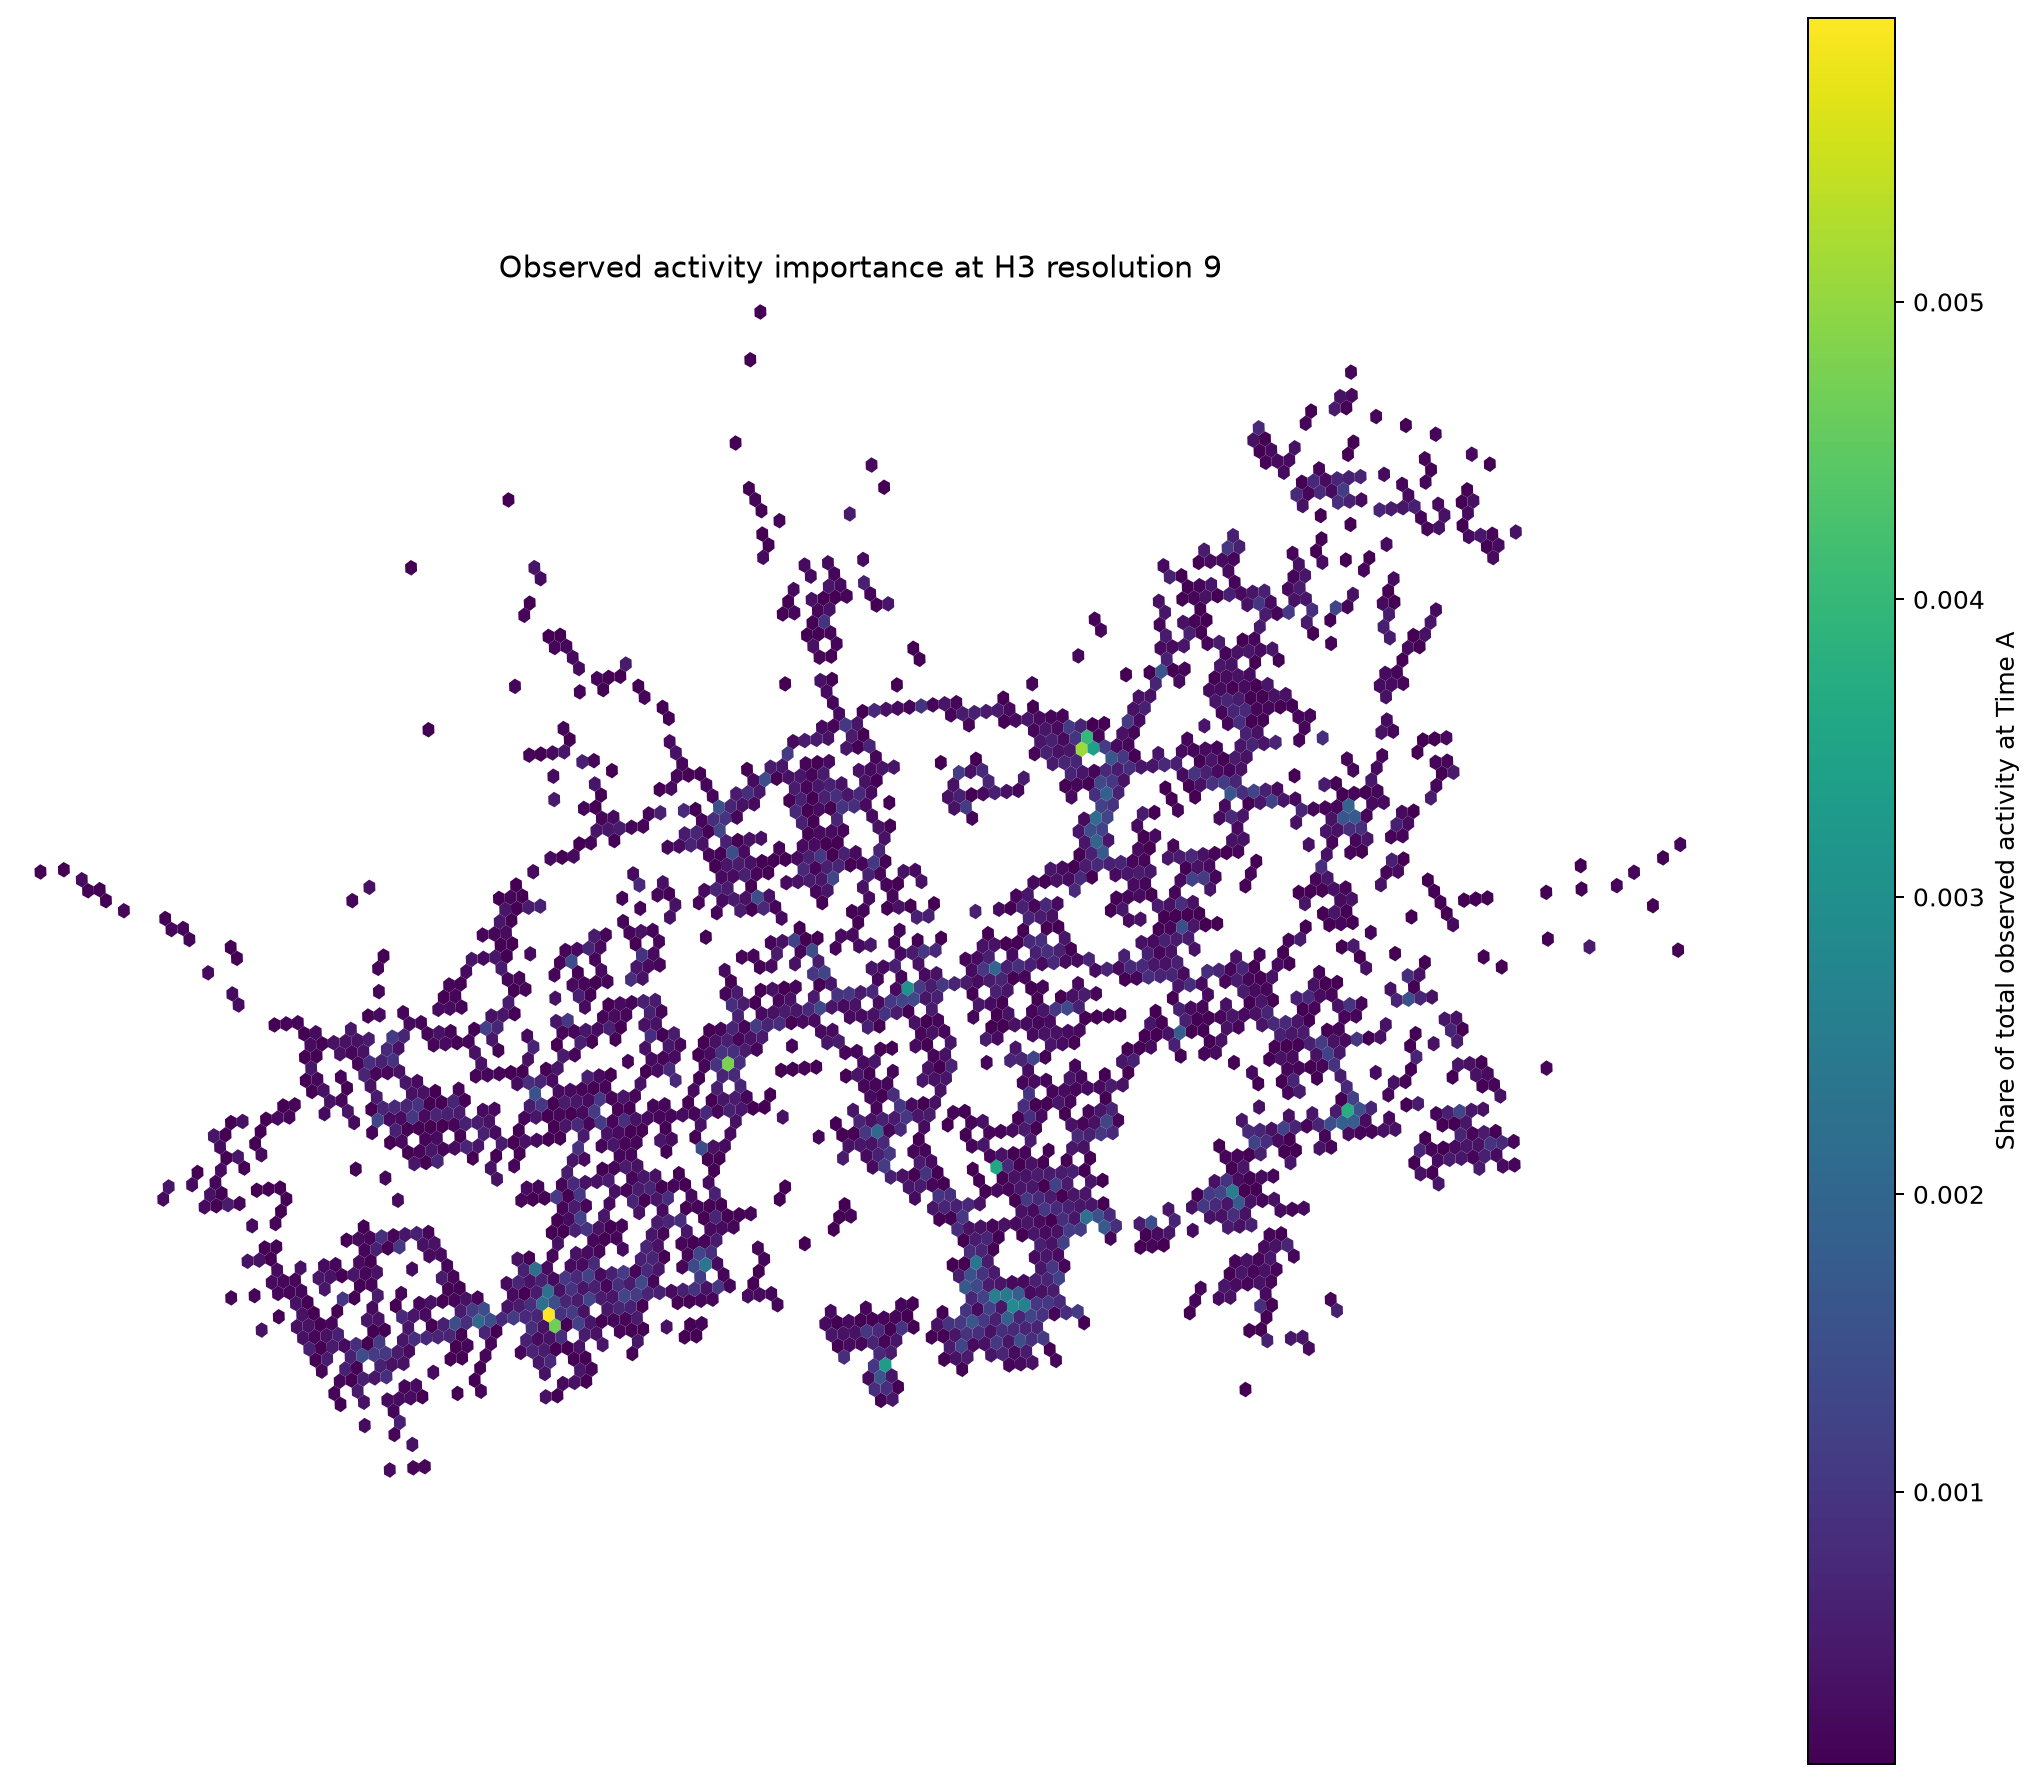

,display_h3,footfall_A,activity_share_A
412,89089969537ffff,70,0.005954
1066,8908996da6bffff,60,0.005104
253,89089968aabffff,56,0.004764
407,89089969523ffff,55,0.004678
1067,8908996da6fffff,47,0.003998
1638,891126d1903ffff,44,0.003743
1378,891126d04c3ffff,42,0.003573
2499,891126d74d3ffff,40,0.003403
2192,891126d36b3ffff,39,0.003317
1784,891126d218bffff,36,0.003062


In [24]:
h3_display["activity_share_A"] = np.where(
    h3_display["footfall_A"].sum() > 0,
    h3_display["footfall_A"]
    / h3_display["footfall_A"].sum(),
    np.nan,
)

plot_h3_surface(
    h3_display,
    column="activity_share_A",
    title=f"Observed activity importance at H3 resolution {MAP_H3_RESOLUTION}",
    legend_label="Share of total observed activity at Time A",
    cmap="viridis",
)

display(
    h3_display[
        [
            "display_h3",
            "footfall_A",
            "activity_share_A",
        ]
    ]
    .sort_values(
        "activity_share_A",
        ascending=False,
    )
    .head(20)
)


## 19C. H3 relative redistribution between Time A and Time B

This measures whether a cell gained or lost **share of total metropolitan activity**, not just raw users.

\[
RelativeShift_h
=
rac{F_{h,B}}{\sum_h F_{h,B}}
-
rac{F_{h,A}}{\sum_h F_{h,A}}
\]

Interpretation:

- positive → the H3 cell became relatively more important;
- negative → the H3 cell lost activity share;
- near zero → its regional importance was broadly stable.

This is useful when total activity differs between the two timestamps.


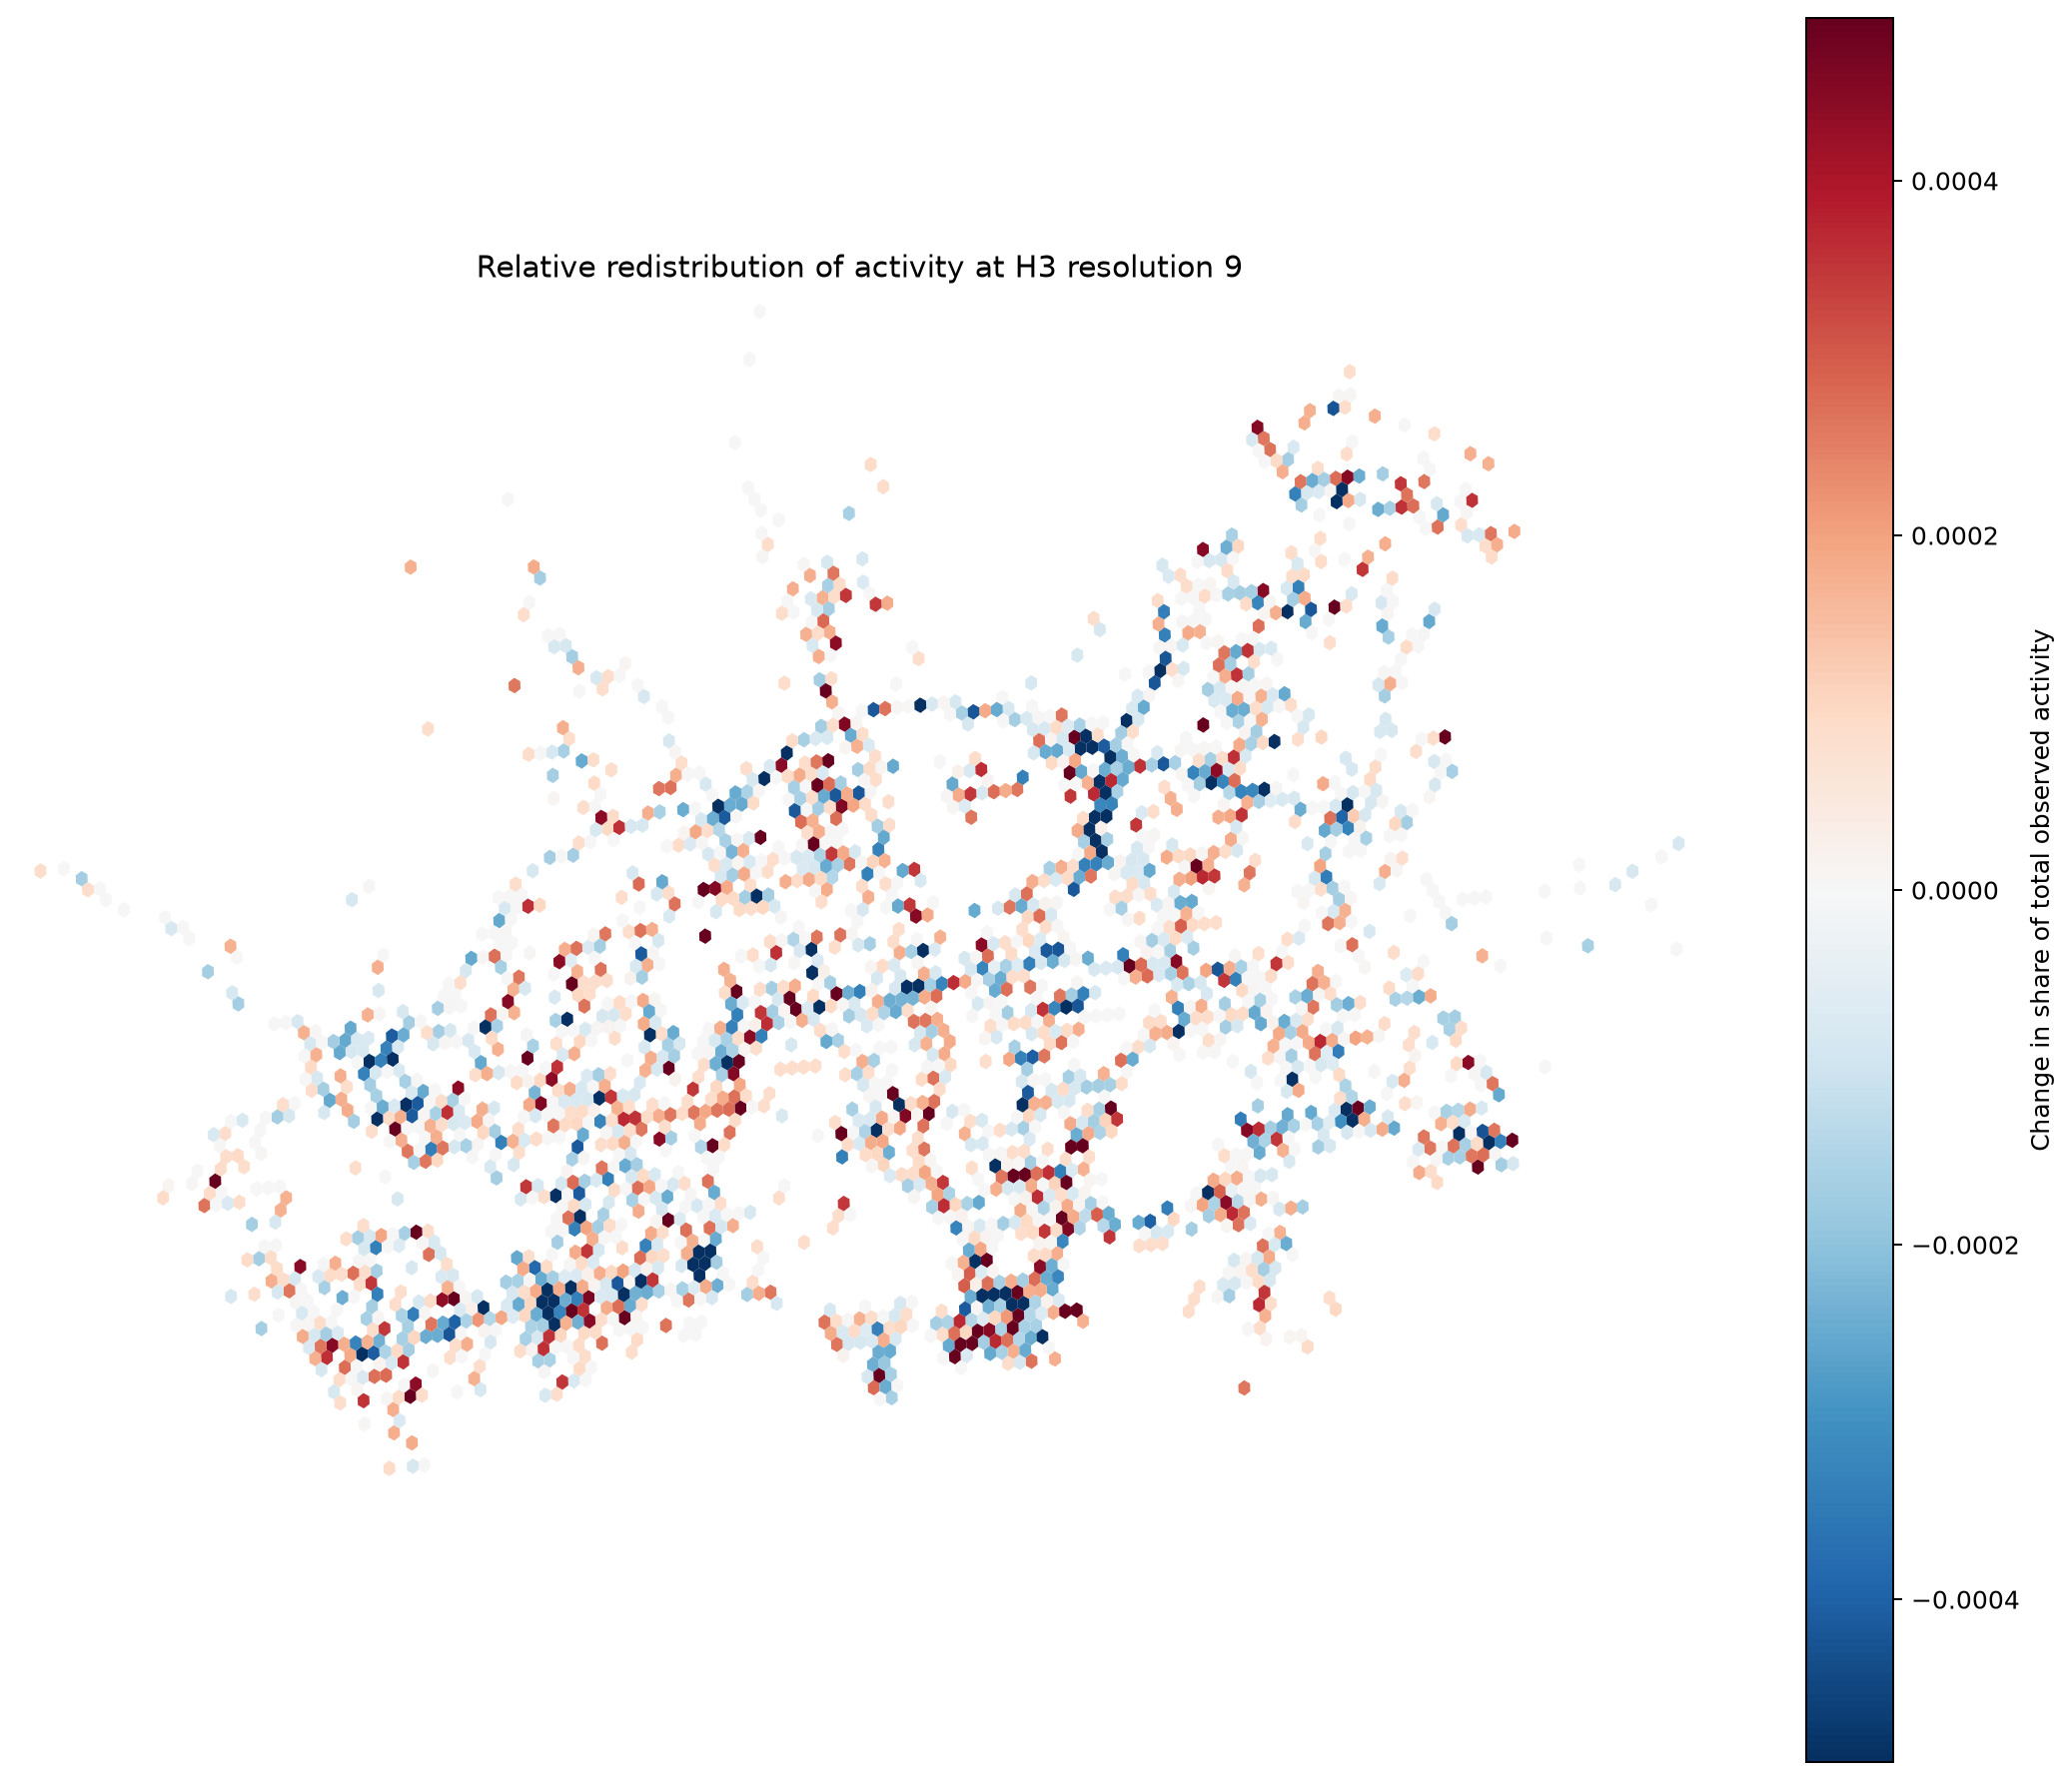

,display_h3,activity_share_A,activity_share_B,relative_activity_shift
2188,891126d3687ffff,0.001616,0.003042,0.001426
2122,891126d3317ffff,0.001786,0.003129,0.001343
238,89089968a33ffff,0.000851,0.002086,0.001236
1641,891126d190fffff,0.001531,0.002434,0.000903
2154,891126d33cfffff,0.000766,0.001652,0.000886
1280,891126c3507ffff,0.000510,0.001391,0.000880
281,89089968b83ffff,0.000510,0.001391,0.000880
2272,891126d4607ffff,0.001276,0.002086,0.000810
1749,891126d2057ffff,0.000851,0.001652,0.000801
89,8908996825bffff,0.001106,0.001825,0.000720


In [25]:
total_A = h3_display["footfall_A"].sum()
total_B = h3_display["footfall_B"].sum()

h3_display["activity_share_A"] = np.where(
    total_A > 0,
    h3_display["footfall_A"] / total_A,
    np.nan,
)

h3_display["activity_share_B"] = np.where(
    total_B > 0,
    h3_display["footfall_B"] / total_B,
    np.nan,
)

h3_display["relative_activity_shift"] = (
    h3_display["activity_share_B"]
    - h3_display["activity_share_A"]
)

shift_limit = np.nanpercentile(
    np.abs(
        h3_display["relative_activity_shift"]
    ),
    95,
)

if not np.isfinite(shift_limit) or shift_limit == 0:
    shift_limit = 1e-6

plot_h3_surface(
    h3_display,
    column="relative_activity_shift",
    title=f"Relative redistribution of activity at H3 resolution {MAP_H3_RESOLUTION}",
    legend_label="Change in share of total observed activity",
    cmap="RdBu_r",
    vmin=-shift_limit,
    vmax=shift_limit,
)

display(
    h3_display[
        [
            "display_h3",
            "activity_share_A",
            "activity_share_B",
            "relative_activity_shift",
        ]
    ]
    .sort_values(
        "relative_activity_shift",
        ascending=False,
    )
    .head(20)
)


## 19D. Multi-hour behavioural persistence from the FF data

The two-time comparison is useful for the POC, but we can also use the full available Locomizer period to ask:

> How often does a spatial cell maintain or increase its activity compared with the **previous day at the same hour**?

For each H3 cell and hour-of-day, the notebook compares one date with the previous available date at that same hour.

A comparison is counted as **persistent** when:

\[
\%\Delta Footfall \ge -5\%
\]

The resulting persistence rate is:

\[
PersistenceRate_h
=
rac{	ext{persistent same-hour comparisons}}
{	ext{all valid same-hour comparisons}}
\]

This is a general FF-based temporal persistence indicator. It is **not conditioned on PM₂.₅**.


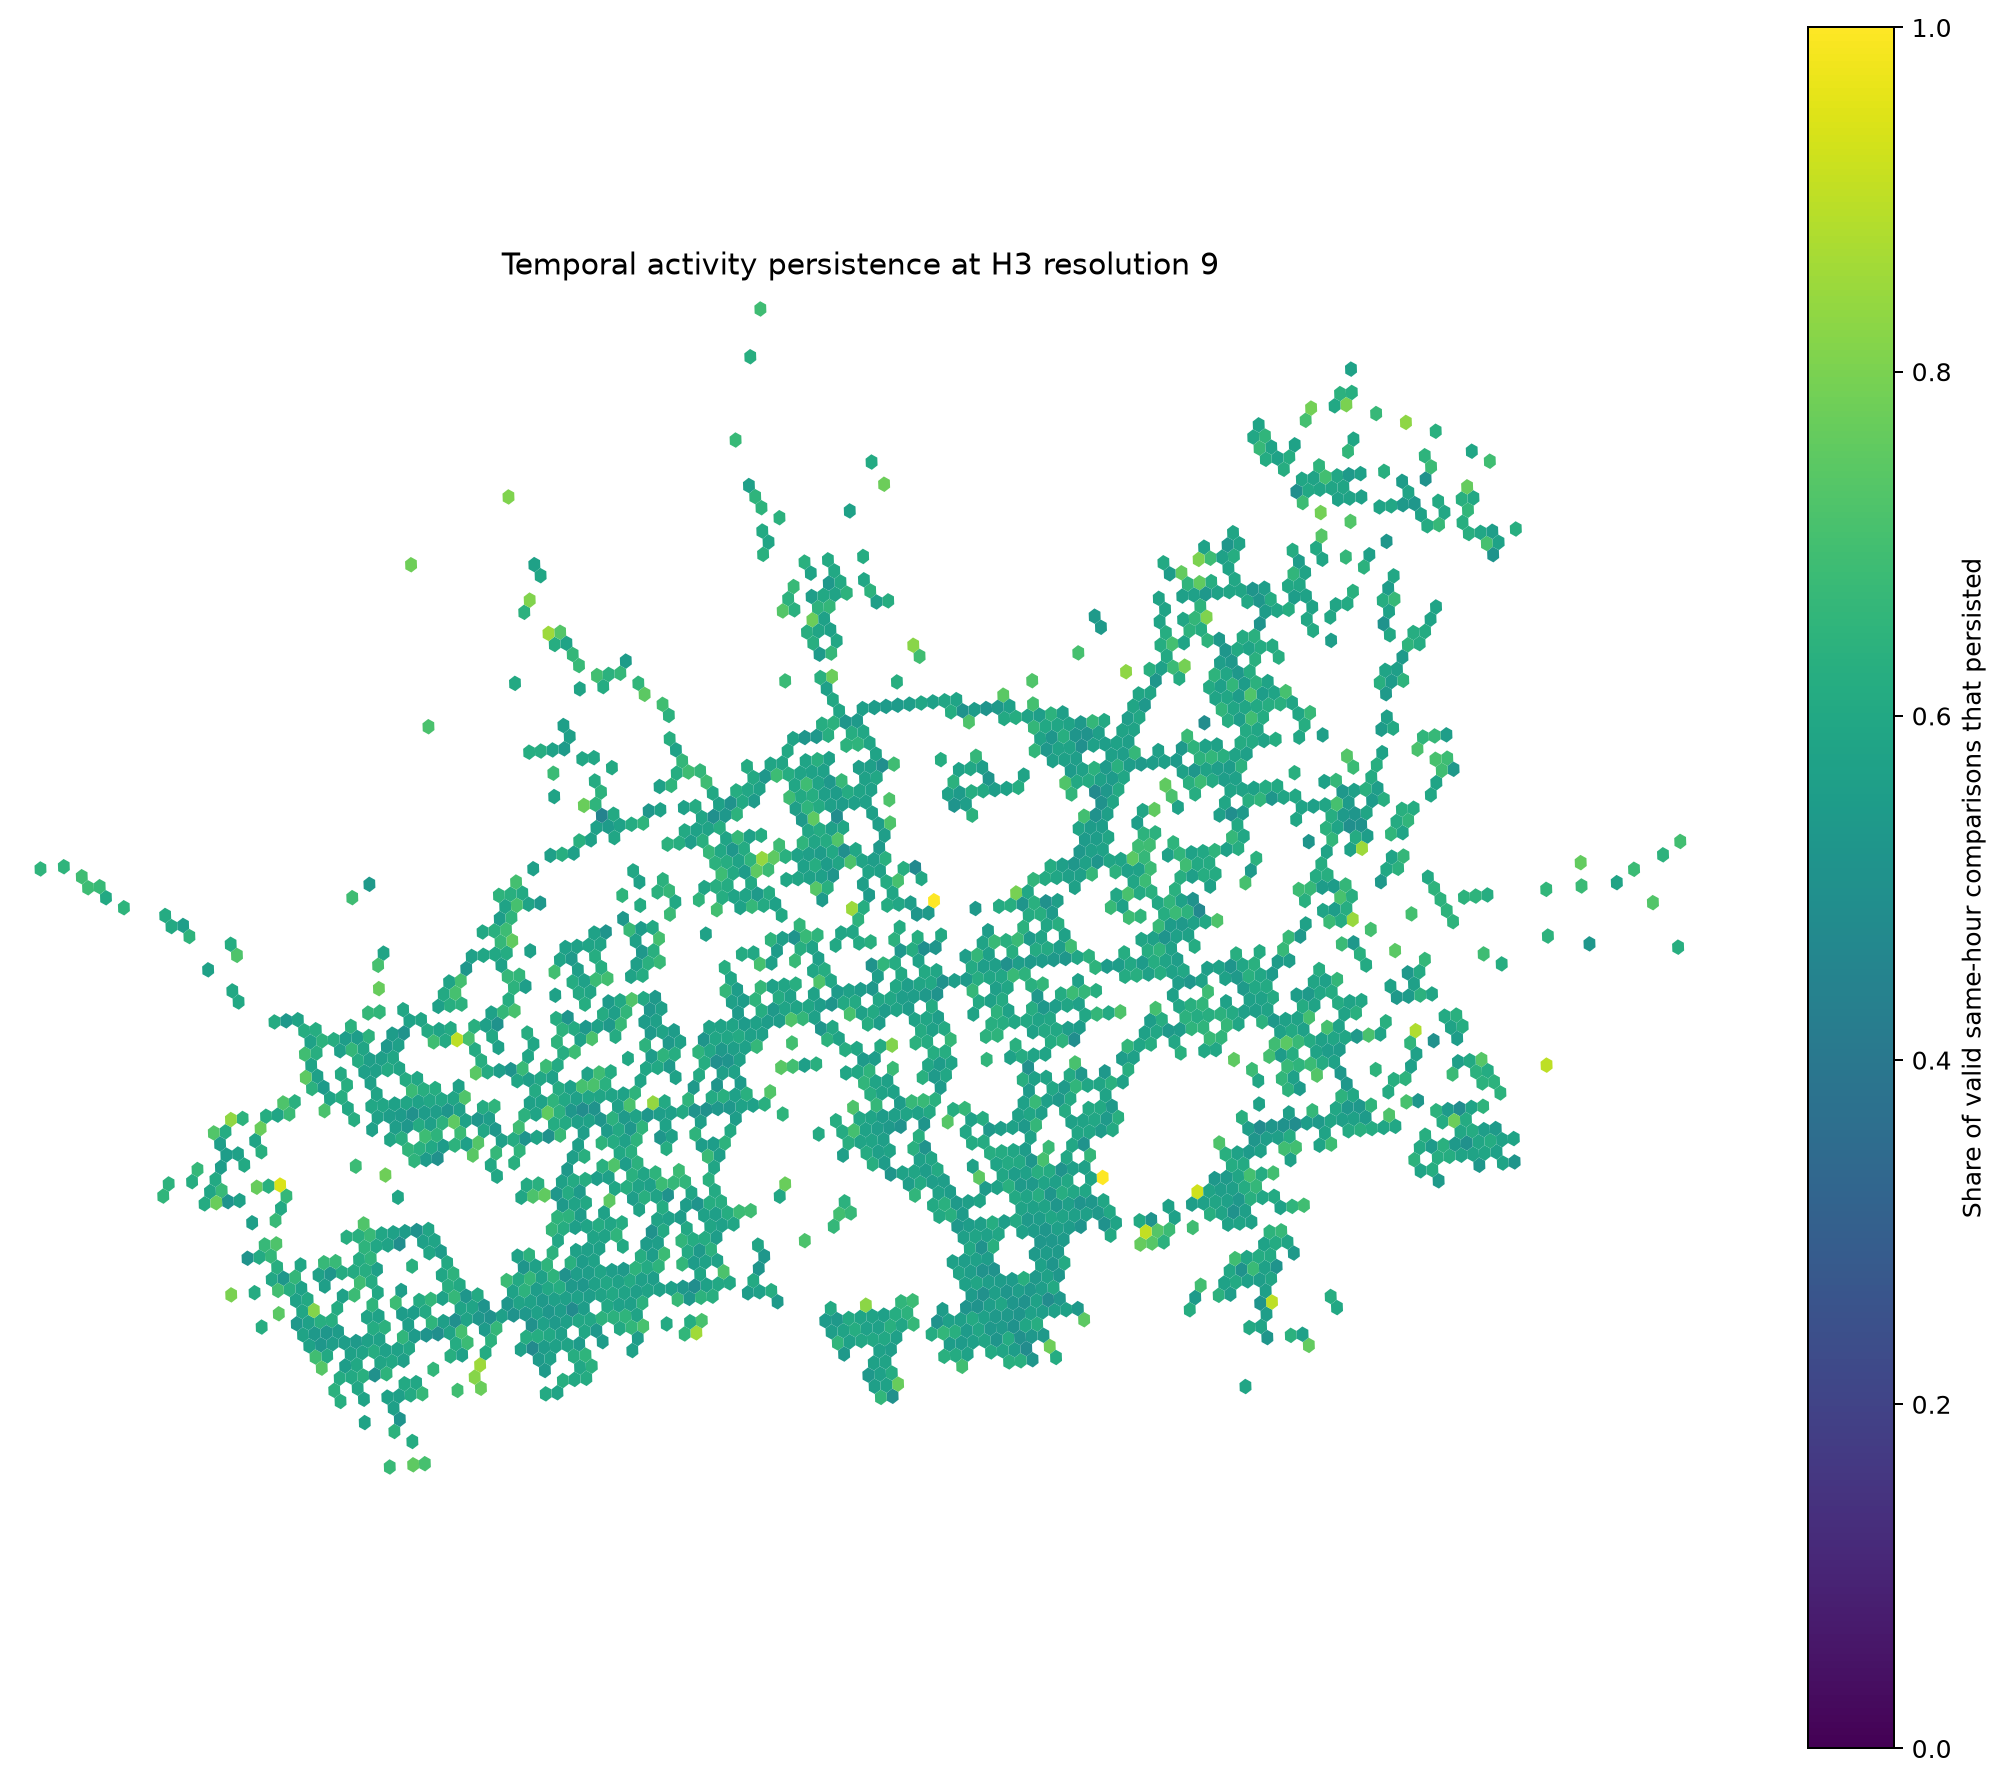

,display_h3,n_same_hour_comparisons,persistence_rate,median_same_hour_pct_change
3699,891126d2c9bffff,26,1.0,0.0
3946,891126d353bffff,24,1.0,0.0
4173,891126d466fffff,23,1.0,0.0
1414,8908996b523ffff,20,1.0,0.0
442,89089968ad7ffff,18,1.0,0.0
2512,891126d0037ffff,18,1.0,0.0
4625,891126d7487ffff,18,1.0,0.0
2003,8908996ebcbffff,16,1.0,0.0
1226,8908996ae27ffff,15,1.0,0.0
1346,8908996b283ffff,15,1.0,0.0


In [26]:
if not LOCOMIZER_FOOTFALL_PARQUET.exists():
    raise FileNotFoundError(
        f"{LOCOMIZER_FOOTFALL_PARQUET} was not found."
    )

ff = pd.read_parquet(
    LOCOMIZER_FOOTFALL_PARQUET
).copy()

ff["date"] = pd.to_datetime(
    ff["date"]
)

ff = ff.loc[
    ff["TIME_INTERVAL"].between(0, 23)
].copy()

# Aggregate native H3-10 cells to the current display resolution first,
# then calculate temporal persistence at that scale.
if MAP_H3_RESOLUTION == 10:
    ff["display_h3"] = ff["CODE"].astype(str)
else:
    ff["display_h3"] = ff["CODE"].map(
        lambda x: h3lib.cell_to_parent(
            str(x),
            MAP_H3_RESOLUTION,
        )
    )

ff_agg = (
    ff
    .groupby(
        [
            "display_h3",
            "date",
            "TIME_INTERVAL",
        ],
        as_index=False,
    )
    .agg(
        footfall=(
            "NUMBER_OF_USERS",
            "sum",
        )
    )
)

ff_agg = ff_agg.sort_values(
    [
        "display_h3",
        "TIME_INTERVAL",
        "date",
    ]
)

ff_agg["previous_footfall"] = (
    ff_agg
    .groupby(
        [
            "display_h3",
            "TIME_INTERVAL",
        ]
    )["footfall"]
    .shift(1)
)

ff_agg["pct_change_vs_previous_day_same_hour"] = np.where(
    ff_agg["previous_footfall"] > 0,
    100
    * (
        ff_agg["footfall"]
        - ff_agg["previous_footfall"]
    )
    / ff_agg["previous_footfall"],
    np.nan,
)

ff_agg["persistent_same_hour"] = (
    ff_agg[
        "pct_change_vs_previous_day_same_hour"
    ]
    >= -STABLE_THRESHOLD_PCT
)

valid_persistence = ff_agg.loc[
    ff_agg[
        "pct_change_vs_previous_day_same_hour"
    ].notna()
].copy()

persistence_summary = (
    valid_persistence
    .groupby(
        "display_h3",
        as_index=False,
    )
    .agg(
        n_same_hour_comparisons=(
            "persistent_same_hour",
            "size",
        ),
        persistence_rate=(
            "persistent_same_hour",
            "mean",
        ),
        median_same_hour_pct_change=(
            "pct_change_vs_previous_day_same_hour",
            "median",
        ),
    )
)

h3_persistence = h3_display[
    [
        "display_h3",
        "geometry",
    ]
].merge(
    persistence_summary,
    on="display_h3",
    how="left",
)

h3_persistence = gpd.GeoDataFrame(
    h3_persistence,
    geometry="geometry",
    crs=h3_display.crs,
)

plot_h3_surface(
    h3_persistence,
    column="persistence_rate",
    title=f"Temporal activity persistence at H3 resolution {MAP_H3_RESOLUTION}",
    legend_label="Share of valid same-hour comparisons that persisted",
    cmap="viridis",
    vmin=0,
    vmax=1,
)

display(
    persistence_summary.sort_values(
        [
            "persistence_rate",
            "n_same_hour_comparisons",
        ],
        ascending=[
            False,
            False,
        ],
    ).head(30)
)


## 19E. Compact FF behavioural profile

These three FF-derived indicators describe different aspects of observed activity:

| Indicator | Meaning |
|---|---|
| `activity_share_A` | how important the H3 cell was at baseline |
| `relative_activity_shift` | whether its share of metropolitan activity rose or fell |
| `persistence_rate` | how consistently activity remained stable/increased across same-hour day-to-day comparisons |

Together they provide a stronger POC than a single two-time percentage-change map.


In [27]:
ff_profile = (
    h3_display[
        [
            "display_h3",
            "footfall_A",
            "footfall_B",
            "pct_change_footfall",
            "activity_share_A",
            "activity_share_B",
            "relative_activity_shift",
        ]
    ]
    .merge(
        persistence_summary,
        on="display_h3",
        how="left",
    )
)

ff_profile["activity_importance_rank"] = (
    ff_profile["activity_share_A"]
    .rank(
        pct=True,
        method="average",
    )
)

ff_profile["persistence_rank"] = (
    ff_profile["persistence_rate"]
    .rank(
        pct=True,
        method="average",
    )
)

ff_profile["poc_priority_score"] = (
    ff_profile["activity_importance_rank"]
    * ff_profile["persistence_rank"]
)

display(
    ff_profile.sort_values(
        "poc_priority_score",
        ascending=False,
    ).head(30)
)


,display_h3,footfall_A,footfall_B,pct_change_footfall,activity_share_A,activity_share_B,relative_activity_shift,n_same_hour_comparisons,persistence_rate,median_same_hour_pct_change,activity_importance_rank,persistence_rank,poc_priority_score
733,8908996b073ffff,10,13,30.000000,0.000851,0.001130,0.000279,215,0.646512,0.000000,0.904126,0.813360,0.735379
437,8908996988bffff,10,2,-80.000000,0.000851,0.000174,-0.000677,191,0.638743,0.000000,0.904126,0.780550,0.705715
1651,891126d1977ffff,8,5,-37.500000,0.000681,0.000435,-0.000246,237,0.649789,0.000000,0.848723,0.826719,0.701655
990,8908996d493ffff,15,13,-13.333333,0.001276,0.001130,-0.000146,204,0.622549,0.000000,0.968173,0.699018,0.676770
1230,891126c242fffff,8,5,-37.500000,0.000681,0.000435,-0.000246,233,0.639485,0.000000,0.848723,0.785462,0.666639
164,89089968553ffff,5,5,0.000000,0.000425,0.000435,0.000009,184,0.733696,0.000000,0.689587,0.965815,0.666014
618,8908996a48bffff,5,4,-20.000000,0.000425,0.000348,-0.000078,96,0.729167,0.000000,0.689587,0.963851,0.664659
1953,891126d2a17ffff,8,5,-37.500000,0.000681,0.000435,-0.000246,166,0.638554,0.000000,0.848723,0.779764,0.661804
1893,891126d26a7ffff,5,3,-40.000000,0.000425,0.000261,-0.000165,176,0.721591,0.000000,0.689587,0.957564,0.660324
1572,891126d0d13ffff,13,17,30.769231,0.001106,0.001478,0.000372,240,0.620833,5.409357,0.951670,0.689194,0.655886


## 20. Save outputs

In [28]:
h3_csv = (
    OUTPUT_DIR / "stage06_h3_behavioural_response.csv"
)

h3_gpkg = (
    OUTPUT_DIR / "stage06_h3_behavioural_response.gpkg"
)

neighbourhood_csv = (
    OUTPUT_DIR / "stage06_neighbourhood_summary.csv"
)

neighbourhood_gpkg = (
    OUTPUT_DIR / "stage06_neighbourhood_summary.gpkg"
)

screening_csv = (
    OUTPUT_DIR / "stage06_h3_behavioural_screening.csv"
)

# Rebuild neighbourhood geometry here explicitly so the save cell
# is independent of any earlier visualization cell.
neighbourhood_map = neighbourhoods.merge(
    neighbourhood_summary,
    on=[
        "unit_id",
        "Neighbourhood_name",
        "Municipality_name",
    ],
    how="left",
)

h3.drop(
    columns="geometry"
).to_csv(
    h3_csv,
    index=False,
)

h3.to_file(
    h3_gpkg,
    layer="h3_behavioural_response",
    driver="GPKG",
)

neighbourhood_summary.to_csv(
    neighbourhood_csv,
    index=False,
)

neighbourhood_map.to_file(
    neighbourhood_gpkg,
    layer="neighbourhood_summary",
    driver="GPKG",
)

screening.to_csv(
    screening_csv,
    index=False,
)

print("Saved:")
for path in [
    h3_csv,
    h3_gpkg,
    neighbourhood_csv,
    neighbourhood_gpkg,
    screening_csv,
]:
    print(" -", path)


aggregated_csv = (
    OUTPUT_DIR
    / f"stage06_h3_res{MAP_H3_RESOLUTION}_behavioural_response.csv"
)

aggregated_gpkg = (
    OUTPUT_DIR
    / f"stage06_h3_res{MAP_H3_RESOLUTION}_behavioural_response.gpkg"
)

h3_display.drop(
    columns="geometry"
).to_csv(
    aggregated_csv,
    index=False,
)

h3_display.to_file(
    aggregated_gpkg,
    layer=f"h3_res{MAP_H3_RESOLUTION}_behavioural_response",
    driver="GPKG",
)

print(" -", aggregated_csv)
print(" -", aggregated_gpkg)



ff_profile_csv = (
    OUTPUT_DIR
    / f"stage06_h3_res{MAP_H3_RESOLUTION}_ff_profile.csv"
)

persistence_csv = (
    OUTPUT_DIR
    / f"stage06_h3_res{MAP_H3_RESOLUTION}_temporal_persistence.csv"
)

persistence_gpkg = (
    OUTPUT_DIR
    / f"stage06_h3_res{MAP_H3_RESOLUTION}_temporal_persistence.gpkg"
)

ff_profile.to_csv(
    ff_profile_csv,
    index=False,
)

persistence_summary.to_csv(
    persistence_csv,
    index=False,
)

h3_persistence.to_file(
    persistence_gpkg,
    layer=f"h3_res{MAP_H3_RESOLUTION}_temporal_persistence",
    driver="GPKG",
)

print(" -", ff_profile_csv)
print(" -", persistence_csv)
print(" -", persistence_gpkg)


Saved:
 - ../outputs/v3/06_h3_behavioural_response/stage06_h3_behavioural_response.csv
 - ../outputs/v3/06_h3_behavioural_response/stage06_h3_behavioural_response.gpkg
 - ../outputs/v3/06_h3_behavioural_response/stage06_neighbourhood_summary.csv
 - ../outputs/v3/06_h3_behavioural_response/stage06_neighbourhood_summary.gpkg
 - ../outputs/v3/06_h3_behavioural_response/stage06_h3_behavioural_screening.csv
 - ../outputs/v3/06_h3_behavioural_response/stage06_h3_res9_behavioural_response.csv
 - ../outputs/v3/06_h3_behavioural_response/stage06_h3_res9_behavioural_response.gpkg
 - ../outputs/v3/06_h3_behavioural_response/stage06_h3_res9_ff_profile.csv
 - ../outputs/v3/06_h3_behavioural_response/stage06_h3_res9_temporal_persistence.csv
 - ../outputs/v3/06_h3_behavioural_response/stage06_h3_res9_temporal_persistence.gpkg


# Interpretation and next step

This stage now prioritizes **observed behavioural change at H3 level**.

The study logic is:

**Regional environmental change → observed H3-level activity response → identify decline, persistence, and increase → focus on high-activity places → only then use CAFEIN, accessibility, and transport-poverty metrics to explain possible constraints on adaptation.**

CAFEIN should therefore become an explanatory mobility-context layer in a later stage rather than the behavioural outcome itself.
